>> Memory-Mapping 5D Arrays from Disk...
>> Data Mapped. MHD Grid Shape: (5, 240, 240, 240) (0.1s)
>> 5D PRODUCTION Grid Created. Total Cells: 22.1 Million
>> GOES position at t=0: (4.499, 4.047, 2.661) RE
>> MPS-LO: 15 usable channels
>> MPS-HI: 11 usable channels
>> Three-population GOES fit:
   Cool Maxwellian: n=10.74168 cm^-3, kT=4.000 keV
   Warm Maxwellian: n=0.03522 cm^-3, kT=7.948 keV
   Hot Kappa      : n=0.156199 cm^-3, kT=9.870 keV, kappa=5.514
   Fit cost=6.80751e-02, success=True
    8.17 keV components: cool=5.592e+06, warm=1.806e+04, kappa=7.142e+04, total=5.681e+06
   90.00 keV components: cool=8.035e-02, warm=6.718e+00, kappa=1.183e+03, total=1.190e+03
>> Vlasov three-population parameters:
   Cool Maxwellian: n=10.741684 cm^-3, kT=4.000000 keV
   Warm Maxwellian: n=0.035223 cm^-3, kT=7.947912 keV
   Hot Kappa      : n=0.156199 cm^-3, kT=9.870020 keV, kappa=5.513723


/var/folders/fm/tq7thpv16nl0ldjt7vprqk4dtl_wz_/T/ipykernel_6388/4141817307.py:449: RuntimeWarning: All-NaN slice encountered
  channel_flux = np.nanmedian(np.nanmax(raw, axis=1), axis=0) if raw.ndim == 3 else (np.nanmedian(raw, axis=0) if raw.ndim == 2 else np.ravel(raw))


>> Common B_geo_ref at (-6.6,0,0) RE: 127.845 nT

INITIAL VLASOV GOES DETECTOR TEST
  8.17 keV | initialized=2.605900e+06 | fit reference=5.854864e+06 | ratio=0.445083
 90.00 keV | initialized=4.979036e+02 | fit reference=1.007783e+03 | ratio=0.494058

>> Initial Vlasov GEO PSD near 8.17 keV: 1.385802e-13
>> Initial Vlasov GEO PSD near 90.00 keV: 2.875196e-18
DEBUG: Max initial f: 5.967312199928188e-10
>> Starting Run (with Boundary Influx Throttling) ...
----------------------------------------------------------------
SEMI-LAGRANGIAN OUTER-STEP DISPLACEMENT DIAGNOSTIC
----------------------------------------------------------------
Outer remap dt: 2.000000 s
Minimum spacings: dx=0.518 RE, dy=0.562 RE, dz=0.224 RE
These values are conservative cell-crossing estimates, not explicit-scheme stability limits.

E=    8.17 keV | v=  1251.0 km/s | worst=  1.75 cells | parallel estimates: 0°=  1.75, 45°=  1.24, 80°=  0.30, 90°=0.00
E=   90.00 keV | v=  4152.1 km/s | worst=  5.81 cells | parall

Simulating:   0%|          | 0/7200.0 [00:00<?, ?it/s]

   [Snapshot 1/22] Saved at Storm Time=0.0 min
   [Snapshot 2/22] Saved at Storm Time=5.7 min
   [Snapshot 3/22] Saved at Storm Time=11.4 min
   [Snapshot 4/22] Saved at Storm Time=17.1 min
   [Snapshot 5/22] Saved at Storm Time=22.9 min
   [Snapshot 6/22] Saved at Storm Time=28.6 min
   [Snapshot 7/22] Saved at Storm Time=34.3 min
   [Snapshot 8/22] Saved at Storm Time=40.0 min
   [Snapshot 9/22] Saved at Storm Time=45.7 min
   [Snapshot 10/22] Saved at Storm Time=51.4 min
   [Snapshot 11/22] Saved at Storm Time=57.1 min
   [Snapshot 12/22] Saved at Storm Time=62.9 min
   [Snapshot 13/22] Saved at Storm Time=68.6 min
   [Snapshot 14/22] Saved at Storm Time=74.3 min
   [Snapshot 15/22] Saved at Storm Time=80.0 min
   [Snapshot 16/22] Saved at Storm Time=85.7 min
   [Snapshot 17/22] Saved at Storm Time=91.4 min
   [Snapshot 18/22] Saved at Storm Time=97.1 min
   [Snapshot 19/22] Saved at Storm Time=102.9 min
   [Snapshot 20/22] Saved at Storm Time=108.6 min
   [Snapshot 21/22] Saved at 

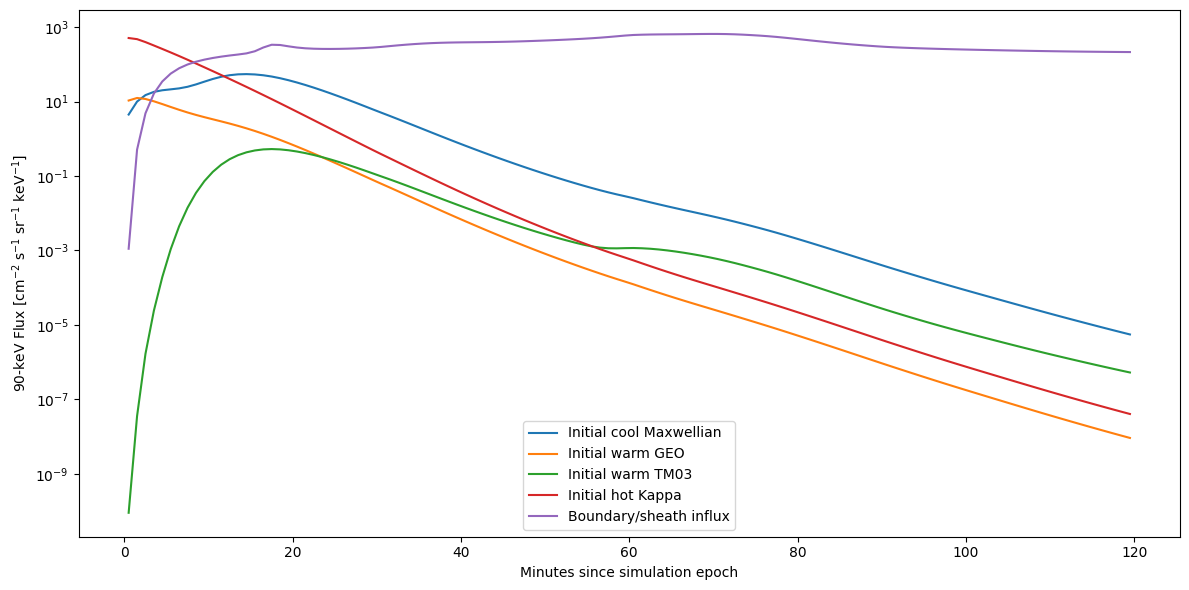

>> Simulation Complete. Processing final diagnostic variables...
>> Visualization data saved securely to GIFs/Distributional/Run_20260928_030537/ProtonSim_Vlasov_20260928_030537_plot_data.pkl
>> CSV files saved. You can now plot without rerunning.


In [1]:
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from numba import njit, prange, float32, set_num_threads
import numba.core
from matplotlib.colors import LogNorm
from datetime import datetime, timezone
import math
import gc
import time
import cdflib
import pickle
import xarray as xr
from xarray.backends import H5netcdfBackendEntrypoint
from scipy.optimize import least_squares
from scipy.special import gammaln
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import h5py
import netCDF4
from scipy.interpolate import RegularGridInterpolator
import geopack

# 1. HARDWARE CONFIGURATION
set_num_threads(8) # Adjust to your core count

# 2. PHYSICAL CONSTANTS (Float64)
RE = np.float64(6.371e6)          # Earth Radius (meters)
q_e = np.float64(1.602e-19)       # Elementary charge (Coulombs)
m_p = np.float64(1.6726219e-27)   # Proton mass (kg)
KP_INDEX = 2.0                    # Geomagnetic activity index      

# Spatial domain boundaries (in Earth Radii)
X_MIN, X_MAX = -15.0 * RE, 10.0 * RE
Y_MIN, Y_MAX = -10.0 * RE, 10.0 * RE
Z_MIN, Z_MAX = -6.5 * RE, 6.5 * RE

INITIAL_Z_MAX, INNER_ABSORBING_RADIUS, INITIAL_EXCLUSION_RADIUS = np.float64(5.0 * RE), np.float64(2.0 * RE), np.float64(2.5 * RE)
SPINUP_TIME, STORM_DURATION = np.float64(0.0), np.float64(7200.0)

# Spectral constraints for initial distributions
MAX_INITIAL_NONHOT_90_FRACTION, NONHOT_90_PENALTY_STRENGTH = np.float64(0.01), np.float64(40.0)
E90_BAND_KEV = np.linspace(72.0, 108.0, 73, dtype=np.float64)

# Vlasov remapping (Semi-Lagrangian time step) and characteristic integration bounds
VLASOV_REMAP_DT, MAX_CHARACTERISTIC_SUBSTEP = np.float32(2.0), np.float32(0.5)

# Virtual Satellite (Detector) configuration
DETECTOR_SAMPLE_DT, DETECTOR_SIGMA_R = np.float64(10.0), np.float64(0.75 * RE)
DETECTOR_CUTOFF_R = np.float64(3.5 * DETECTOR_SIGMA_R)

N_SOURCES = 5
SRC_COOL, SRC_WARM_GEO, SRC_WARM_TM03, SRC_HOT_KAPPA, SRC_BOUNDARY = 0, 1, 2, 3, 4

# =============================================================================
# BLOCK 1: DATA LOADING (MEMORY MAPPED FOR LOW RAM)
# Maps precomputed Magnetohydrodynamic (MHD) background fields into memory.
# =============================================================================
print(">> Memory-Mapping 5D Arrays from Disk...")
start_t = time.time()
data_dir = "mmap_data"

try:
    mhd_data = {
        'Bx': np.load(f"{data_dir}/mhd_Bx.npy", mmap_mode='r'), 'By': np.load(f"{data_dir}/mhd_By.npy", mmap_mode='r'), 'Bz': np.load(f"{data_dir}/mhd_Bz.npy", mmap_mode='r'),
        'Vx': np.load(f"{data_dir}/mhd_Vx.npy", mmap_mode='r'), 'Vy': np.load(f"{data_dir}/mhd_Vy.npy", mmap_mode='r'), 'Vz': np.load(f"{data_dir}/mhd_Vz.npy", mmap_mode='r'),
        'gradBx': np.load(f"{data_dir}/mhd_gradBx.npy", mmap_mode='r'), 'gradBy': np.load(f"{data_dir}/mhd_gradBy.npy", mmap_mode='r'), 'gradBz': np.load(f"{data_dir}/mhd_gradBz.npy", mmap_mode='r'),
        'kappaX': np.load(f"{data_dir}/mhd_kappaX.npy", mmap_mode='r'), 'kappaY': np.load(f"{data_dir}/mhd_kappaY.npy", mmap_mode='r'), 'kappaZ': np.load(f"{data_dir}/mhd_kappaZ.npy", mmap_mode='r'),
        'n_bnd': np.load(f"{data_dir}/mhd_n_bnd.npy", mmap_mode='r'), 'kT_bnd': np.load(f"{data_dir}/mhd_kT_bnd.npy", mmap_mode='r')
    }
    grid_t, grid_x, grid_y, grid_z = (np.load(f"{data_dir}/mhd_grid_t.npy"), np.load(f"{data_dir}/mhd_grid_x.npy"), np.load(f"{data_dir}/mhd_grid_y.npy"), np.load(f"{data_dir}/mhd_grid_z.npy"))
    print(f">> Data Mapped. MHD Grid Shape: {mhd_data['Bx'].shape} ({time.time() - start_t:.1f}s)")
except FileNotFoundError as e:
    print(f"!! CRITICAL ERROR: Missing mapped data files in '{data_dir}': {e}"); raise e

# =============================================================================
# BLOCK 2: NON-UNIFORM (STRETCHED) VLASOV GRID
# Creates the 5-dimensional grid (X, Y, Z, Energy, Pitch Angle). 
# Uses higher resolution where gradients are steep (e.g., near Earth).
# =============================================================================
def check_semilagrangian_displacement(sim_x, sim_y, sim_z, energies_J, m, dt):
    """Diagnostic tool to estimate how many grid cells particles cross per timestep (CFL-like check)."""
    dx_min, dy_min, dz_min = float(np.min(np.diff(sim_x))), float(np.min(np.diff(sim_y))), float(np.min(np.diff(sim_z)))
    dmin = min(dx_min, dy_min, dz_min)
    energies_J, speeds = np.atleast_1d(np.asarray(energies_J, dtype=np.float64)), np.sqrt(2.0 * energies_J / float(m))
    print("-" * 64 + f"\nSEMI-LAGRANGIAN OUTER-STEP DISPLACEMENT DIAGNOSTIC\n" + "-" * 64)
    print(f"Outer remap dt: {float(dt):.6f} s\nMinimum spacings: dx={dx_min/float(RE):.3f} RE, dy={dy_min/float(RE):.3f} RE, dz={dz_min/float(RE):.3f} RE\nThese values are conservative cell-crossing estimates, not explicit-scheme stability limits.\n")
    max_cfl = 0.0
    for energy_J, speed in zip(energies_J, speeds):
        energy_keV = energy_J / (1000.0 * float(q_e))
        c_ballistic = speed * float(dt) / dmin
        max_cfl = max(max_cfl, c_ballistic)
        print(f"E={energy_keV:8.2f} keV | v={speed/1.0e3:8.1f} km/s | worst={c_ballistic:6.2f} cells | parallel estimates: 0°={c_ballistic:6.2f}, 45°={c_ballistic * np.cos(np.radians(45.0)):6.2f}, 80°={c_ballistic * np.cos(np.radians(80.0)):6.2f}, 90°=0.00")
    print(f"\nMaximum conservative outer displacement: {max_cfl:.2f} cells\n" + "-" * 64)
    return max_cfl

def create_smooth_focused_grid(min_val, max_val, foci, n_points, width=1.5*RE, background=0.1):
    """Creates a non-uniform 1D array concentrated around specific 'foci'."""
    fine_x, density = np.linspace(min_val, max_val, 10000), np.full(10000, background)
    for f in foci: density += 1.0 / (1.0 + ((fine_x - f) / width)**2)
    cdf = np.cumsum(density)
    cdf = (cdf - cdf[0]) / (cdf[-1] - cdf[0]) 
    return np.interp(np.linspace(0, 1, n_points), cdf, fine_x).astype(np.float32)

@njit(fastmath=True)
def precompute_phase_space_weights(sE, sAlpha, m):
    """Calculates Jacobian integration weights for Volume = E^(1/2) * sin(alpha) dE dAlpha."""
    nE, nAlpha = len(sE), len(sAlpha)
    weights, m_64, coef_64 = np.zeros((nE, nAlpha), dtype=np.float32), np.float64(m), 2.0 * np.pi * np.sqrt(2.0)
    for l in range(nE):
        E_upper = np.sqrt(sE[0] * sE[1]) if l == 0 else (sE[-1] if l == nE - 1 else np.sqrt(sE[l] * sE[l+1]))
        E_lower = sE[0] if l == 0 else (np.sqrt(sE[-2] * sE[-1]) if l == nE - 1 else np.sqrt(sE[l-1] * sE[l]))
        dE = E_upper - E_lower
        for p in range(nAlpha):
            da = sAlpha[1] - sAlpha[0] if p == 0 else (sAlpha[-1] - sAlpha[-2] if p == nAlpha - 1 else np.float32(0.5) * (sAlpha[p+1] - sAlpha[p-1]))
            weights[l, p] = np.float32((coef_64 * np.sqrt(np.float64(sE[l])) / (m_64 ** 1.5) * np.sin(np.float64(sAlpha[p])) * np.float64(dE) * np.float64(da)))
    return weights

@njit(fastmath=True)
def precompute_cell_widths(s):
    n = len(s); w = np.empty(n, dtype=np.float32)
    w[0], w[n-1] = s[1] - s[0], s[n-1] - s[n-2]
    for i in range(1, n-1): w[i] = np.float32(0.5) * (s[i+1] - s[i-1])
    return w

# 5D Production Grid Initialization
geo_and_tail_foci = [-11.0 * RE, -6.6 * RE, -1.0 * RE, 1.0 * RE, 6.6 * RE, 8.0 * RE]
sim_x = create_smooth_focused_grid(X_MIN, X_MAX, foci=geo_and_tail_foci, n_points=40, width=4.0 * RE, background=0.2)
sim_y = create_smooth_focused_grid(Y_MIN, Y_MAX, foci=geo_and_tail_foci, n_points=32, width=4.0 * RE, background=0.2)
sim_z = create_smooth_focused_grid(Z_MIN, Z_MAX, foci=[0.0], n_points=27, width=2.0 * RE)
E_min, E_max = np.float32(0.01 * 1000 * q_e), np.float32(1000.0 * 1000 * q_e) # 10 eV to 1 MeV
sim_Ek = np.geomspace(E_min, E_max, 40, dtype=np.float32)
sim_Ek_log = np.log(sim_Ek).astype(np.float32)
sim_alpha = create_smooth_focused_grid(0.01, np.pi - 0.01, foci=[0.05, np.pi/2.0, np.pi - 0.05], n_points=16, width=0.2)

phase_weights = precompute_phase_space_weights(sim_Ek, sim_alpha, m_p)
dx_widths, dy_widths, dz_widths = precompute_cell_widths(sim_x), precompute_cell_widths(sim_y), precompute_cell_widths(sim_z)
dE_widths, dalpha_widths = precompute_cell_widths(sim_Ek), precompute_cell_widths(sim_alpha)
print(f">> 5D PRODUCTION Grid Created. Total Cells: {len(sim_x)*len(sim_y)*len(sim_z)*len(sim_Ek)*len(sim_alpha) / 1e6:.1f} Million")

# =============================================================================
# BLOCK 3: SCALAR PHYSICS LOGIC
# Contains Numba-optimized functions for Field Interpolation, E-Fields,
# Drift Velocities, and Boundary Condition Distributions.
# =============================================================================
@njit(fastmath=True)
def fast_cross(ax, ay, az, bx, by, bz):
    return np.float32(ay * bz - az * by), np.float32(az * bx - ax * bz), np.float32(ax * by - ay * bx)

@njit(fastmath=True)
def get_interp_weights_3d(px, py, pz, x_grid, y_grid, z_grid):
    """Calculates tri-linear interpolation indices and weights."""
    ix, iy, iz = max(0, min(np.searchsorted(x_grid, px) - 1, len(x_grid) - 2)), max(0, min(np.searchsorted(y_grid, py) - 1, len(y_grid) - 2)), max(0, min(np.searchsorted(z_grid, pz) - 1, len(z_grid) - 2))
    xd, yd, zd = max(0.0, min(1.0, (px - x_grid[ix]) / (x_grid[ix+1] - x_grid[ix]))), max(0.0, min(1.0, (py - y_grid[iy]) / (y_grid[iy+1] - y_grid[iy]))), max(0.0, min(1.0, (pz - z_grid[iz]) / (z_grid[iz+1] - z_grid[iz])))
    return ix, iy, iz, np.float32(xd), np.float32(yd), np.float32(zd)

@njit(fastmath=True)
def apply_interp_3d(ix, iy, iz, xd, yd, zd, data):
    omm_xd = np.float32(1.0) - xd
    c00, c01 = data[ix, iy, iz] * omm_xd + data[ix+1, iy, iz] * xd, data[ix, iy, iz+1] * omm_xd + data[ix+1, iy, iz+1] * xd
    c10, c11 = data[ix, iy+1, iz] * omm_xd + data[ix+1, iy+1, iz] * xd, data[ix, iy+1, iz+1] * omm_xd + data[ix+1, iy+1, iz+1] * xd
    return (c00*(np.float32(1.0)-yd) + c10*yd)*(np.float32(1.0)-zd) + (c01*(np.float32(1.0)-yd) + c11*yd)*zd

@njit(fastmath=True)
def get_interp_weights_4d(t, px, py, pz, t_grid, x_grid, y_grid, z_grid):
    """Calculates 4D spatio-temporal interpolation weights."""
    it, ix, iy, iz = max(0, min(np.searchsorted(t_grid, t) - 1, len(t_grid) - 2)), max(0, min(np.searchsorted(x_grid, px) - 1, len(x_grid) - 2)), max(0, min(np.searchsorted(y_grid, py) - 1, len(y_grid) - 2)), max(0, min(np.searchsorted(z_grid, pz) - 1, len(z_grid) - 2))
    td, xd = max(0.0, min(1.0, (t - t_grid[it]) / (t_grid[it+1] - t_grid[it]))), max(0.0, min(1.0, (px - x_grid[ix]) / (x_grid[ix+1] - x_grid[ix])))
    yd, zd = max(0.0, min(1.0, (py - y_grid[iy]) / (y_grid[iy+1] - y_grid[iy]))), max(0.0, min(1.0, (pz - z_grid[iz]) / (z_grid[iz+1] - z_grid[iz])))
    return it, ix, iy, iz, np.float32(td), np.float32(xd), np.float32(yd), np.float32(zd)

@njit(fastmath=True)
def apply_interp_4d(it, ix, iy, iz, td, xd, yd, zd, data):
    omm_td, omm_xd, omm_yd, omm_zd = np.float32(1.0) - td, np.float32(1.0) - xd, np.float32(1.0) - yd, np.float32(1.0) - zd
    c00_0, c01_0 = data[it, ix, iy, iz]*omm_xd + data[it, ix+1, iy, iz]*xd, data[it, ix, iy, iz+1]*omm_xd + data[it, ix+1, iy, iz+1]*xd
    c10_0, c11_0 = data[it, ix, iy+1, iz]*omm_xd + data[it, ix+1, iy+1, iz]*xd, data[it, ix, iy+1, iz+1]*omm_xd + data[it, ix+1, iy+1, iz+1]*xd
    val0 = (c00_0*omm_yd + c10_0*yd)*omm_zd + (c01_0*omm_yd + c11_0*yd)*zd
    c00_1, c01_1 = data[it+1, ix, iy, iz]*omm_xd + data[it+1, ix+1, iy, iz]*xd, data[it+1, ix, iy, iz+1]*omm_xd + data[it+1, ix+1, iy, iz+1]*xd
    c10_1, c11_1 = data[it+1, ix, iy+1, iz]*omm_xd + data[it+1, ix+1, iy+1, iz]*xd, data[it+1, ix, iy+1, iz+1]*omm_xd + data[it+1, ix+1, iy+1, iz+1]*xd
    val1 = (c00_1*omm_yd + c10_1*yd)*omm_zd + (c01_1*omm_yd + c11_1*yd)*zd
    return val0 * omm_td + val1 * td

@njit(fastmath=True)
def fast_vec_4d_preweighted(it, ix, iy, iz, td, xd, yd, zd, d_x, d_y, d_z):
    return apply_interp_4d(it, ix, iy, iz, td, xd, yd, zd, d_x), apply_interp_4d(it, ix, iy, iz, td, xd, yd, zd, d_y), apply_interp_4d(it, ix, iy, iz, td, xd, yd, zd, d_z)

@njit(fastmath=True)
def get_volland_stern_E(px, py, pz, bx, by, bz, Kp):
    """Computes the empirical Volland-Stern Electric Field (convection E-field) for the inner magnetosphere."""
    r_sq_2d = px*px + py*py
    if r_sq_2d < 1e-10: return 0.0, 0.0, 0.0
    r_2d, denom = np.sqrt(r_sq_2d), 1.0 - 0.159 * Kp + 0.0093 * (Kp**2)
    A = 45.0 / (denom**3) 
    Ex, Ey, Ez = A * (px * py) / (RE**2 * r_2d), A * (px*px + 2.0 * py*py) / (RE**2 * r_2d), 0.0
    Bmag = np.sqrt(bx*bx + by*by + bz*bz) + 1e-30
    bhx, bhy, bhz = bx/Bmag, by/Bmag, bz/Bmag
    E_dot_b = Ex * bhx + Ey * bhy + Ez * bhz
    return np.float32(Ex - E_dot_b * bhx), np.float32(Ey - E_dot_b * bhy), np.float32(Ez - E_dot_b * bhz)

@njit(fastmath=True)
def get_fields_gc_preweighted(it, ix, iy, iz, td, xd, yd, zd, px, py, pz, calc_E, mbx, mby, mbz, mvx, mvy, mvz, omega_earth_gsm):
    """Gets total B and E fields, blending Outer MHD E-fields with Inner empirical E-fields (Volland-Stern + Corotation)."""
    r_sq, r_mag = px*px + py*py + pz*pz, np.float32(np.sqrt(px*px + py*py + pz*pz))
    r_re = r_mag / np.float32(6.371e6)
    
    bx_raw, by_raw, bz_raw = fast_vec_4d_preweighted(it, ix, iy, iz, td, xd, yd, zd, mbx, mby, mbz)
    bx, by, bz = bx_raw * np.float32(1e-9), by_raw * np.float32(1e-9), bz_raw * np.float32(1e-9)
    if not calc_E: return np.float32(0.0), np.float32(0.0), np.float32(0.0), bx, by, bz
        
    R_IN_E, R_OUT_E = np.float32(3.0), np.float32(4.0)
    vx_raw, vy_raw, vz_raw = fast_vec_4d_preweighted(it, ix, iy, iz, td, xd, yd, zd, mvx, mvy, mvz)
    vx, vy, vz = vx_raw * np.float32(1e3), vy_raw * np.float32(1e3), vz_raw * np.float32(1e3)
    Emx, Emy, Emz = fast_cross(bx, by, bz, vx, vy, vz) # MHD E = -V x B
    
    # Inner Magnetosphere E (Volland-Stern + Corotation)
    Evx, Evy, Evz = get_volland_stern_E(px, py, pz, bx, by, bz, KP_INDEX)
    alpha_cor = np.float32(max(0.0, min(1.0, (3.1855e7 - r_mag) / 9.5565e6)))
    vco_x, vco_y, vco_z = np.float32(omega_earth_gsm[1]) * pz - np.float32(omega_earth_gsm[2]) * py, np.float32(omega_earth_gsm[2]) * px - np.float32(omega_earth_gsm[0]) * pz, np.float32(omega_earth_gsm[0]) * py - np.float32(omega_earth_gsm[1]) * px
    Ecox, Ecoy, Ecoz = fast_cross(bx, by, bz, vco_x, vco_y, vco_z)
    Einx, Einy, Einz = Evx + alpha_cor * Ecox, Evy + alpha_cor * Ecoy, Evz + alpha_cor * Ecoz

    # Blending zone
    if r_re <= R_IN_E: Ex, Ey, Ez = Einx, Einy, Einz
    elif r_re >= R_OUT_E: Ex, Ey, Ez = Emx, Emy, Emz
    else:
        x_frac = (r_re - R_IN_E) / (R_OUT_E - R_IN_E)
        w, omm_w = x_frac * x_frac * (np.float32(3.0) - np.float32(2.0) * x_frac), np.float32(1.0) - (x_frac * x_frac * (np.float32(3.0) - np.float32(2.0) * x_frac))
        Ex, Ey, Ez = omm_w * Einx + w * Emx, omm_w * Einy + w * Emy, omm_w * Einz + w * Emz
    return Ex, Ey, Ez, bx, by, bz

@njit(fastmath=True)
def get_gc_derivatives_vlasov(t, x, y, z, v_par, mu, q, m, delta, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, mgbx, mgby, mgbz, mkx, mky, mkz, omega_earth_gsm):
    """Coupled guiding-center spatial and velocity derivatives for Vlasov characteristic tracing."""
    Ex, Ey, Ez, bx, by, bz = get_fields_gc(t, x, y, z, True, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, omega_earth_gsm)
    gbx, gby, gbz, kx, ky, kz, Bmag, bhx, bhy, bhz = get_gradB_kappa(t, x, y, z, bx, by, bz, delta, gt, gx, gy, gz, mbx, mby, mbz, mgbx, mgby, mgbz, mkx, mky, mkz)

    B_sq_inv = np.float32(1.0) / (Bmag * Bmag + np.float32(1e-30))

    # E x B Drift
    cx, cy, cz = fast_cross(Ex, Ey, Ez, bhx, bhy, bhz)
    vEx_x, vEx_y, vEx_z = cx / Bmag, cy / Bmag, cz / Bmag

    # Gradient B Drift
    fac_gradB = mu / (np.float32(q) * Bmag + np.float32(1e-30))
    cx, cy, cz = fast_cross(bhx, bhy, bhz, gbx, gby, gbz)
    vgb_x, vgb_y, vgb_z = cx * fac_gradB, cy * fac_gradB, cz * fac_gradB

    # Curvature Drift
    fac_curv = (np.float32(m) * v_par * v_par) / (np.float32(q) * Bmag + np.float32(1e-30))
    cx, cy, cz = fast_cross(bhx, bhy, bhz, kx, ky, kz)
    vcv_x, vcv_y, vcv_z = cx * fac_curv, cy * fac_curv, cz * fac_curv

    # Total GC spatial velocity
    x_dot, y_dot, z_dot = v_par * bhx + vEx_x + vgb_x + vcv_x, v_par * bhy + vEx_y + vgb_y + vcv_y, v_par * bhz + vEx_z + vgb_z + vcv_z

    # Parallel acceleration
    b_dot_gradB = bhx * gbx + bhy * gby + bhz * gbz
    E_dot_b = Ex * bhx + Ey * bhy + Ez * bhz
    v_par_dot = -(mu / np.float32(m)) * b_dot_gradB + (np.float32(q) / np.float32(m)) * E_dot_b

    return np.float32(x_dot), np.float32(y_dot), np.float32(z_dot), np.float32(v_par_dot), Bmag

@njit(fastmath=True)
def get_gradB_kappa_preweighted(it, ix, iy, iz, td, xd, yd, zd, bx, by, bz, delta, mgbx, mgby, mgbz, mkx, mky, mkz):
    Bmag = np.float32(np.sqrt(bx*bx + by*by + bz*bz)) + np.float32(1e-30)
    bh_x, bh_y, bh_z = bx / Bmag, by / Bmag, bz / Bmag
    gb_rx, gb_ry, gb_rz = fast_vec_4d_preweighted(it, ix, iy, iz, td, xd, yd, zd, mgbx, mgby, mgbz)
    kx, ky, kz = fast_vec_4d_preweighted(it, ix, iy, iz, td, xd, yd, zd, mkx, mky, mkz)
    return gb_rx * np.float32(1e-9), gb_ry * np.float32(1e-9), gb_rz * np.float32(1e-9), kx, ky, kz, Bmag, bh_x, bh_y, bh_z

@njit(fastmath=True)
def get_fields_gc(t, px, py, pz, calc_E, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, omega_earth_gsm):
    it, ix, iy, iz, td, xd, yd, zd = get_interp_weights_4d(t, px, py, pz, gt, gx, gy, gz)
    return get_fields_gc_preweighted(it, ix, iy, iz, td, xd, yd, zd, px, py, pz, calc_E, mbx, mby, mbz, mvx, mvy, mvz, omega_earth_gsm)

@njit(fastmath=True)
def get_gradB_kappa(t, px, py, pz, bx, by, bz, delta, gt, gx, gy, gz, mbx, mby, mbz, mgbx, mgby, mgbz, mkx, mky, mkz): 
    it, ix, iy, iz, td, xd, yd, zd = get_interp_weights_4d(t, px, py, pz, gt, gx, gy, gz)
    return get_gradB_kappa_preweighted(it, ix, iy, iz, td, xd, yd, zd, bx, by, bz, delta, mgbx, mgby, mgbz, mkx, mky, mkz)

@njit(fastmath=True)
def phase_to_velocity(Ek, alpha, phi, bhx, bhy, bhz, Ex, Ey, Ez, Bmag, m):
    """Converts local Energy, Pitch Angle, and Gyrophase into 3D cartesian velocity."""
    v_tot, v_par, v_perp_mag = np.float32(np.sqrt(2.0 * Ek / m)), np.float32(np.sqrt(2.0 * Ek / m)) * np.float32(np.cos(alpha)), np.float32(np.sqrt(2.0 * Ek / m)) * np.float32(np.sin(alpha))
    tx, ty, tz = (np.float32(1.0), np.float32(0.0), np.float32(0.0)) if np.abs(bhy) > np.float32(0.9) else (np.float32(0.0), np.float32(1.0), np.float32(0.0))
    e1_x, e1_y, e1_z = fast_cross(bhx, bhy, bhz, tx, ty, tz)
    e1_mag = np.float32(np.sqrt(e1_x*e1_x + e1_y*e1_y + e1_z*e1_z))
    e1_x, e1_y, e1_z = e1_x/(e1_mag + 1e-30), e1_y/(e1_mag + 1e-30), e1_z/(e1_mag + 1e-30)
    e2_x, e2_y, e2_z = fast_cross(bhx, bhy, bhz, e1_x, e1_y, e1_z)
    
    cphi, sphi = np.float32(np.cos(phi)), np.float32(np.sin(phi))
    vpx, vpy, vpz = v_perp_mag * (cphi * e1_x + sphi * e2_x), v_perp_mag * (cphi * e1_y + sphi * e2_y), v_perp_mag * (cphi * e1_z + sphi * e2_z)
    cx, cy, cz = fast_cross(Ex, Ey, Ez, bhx, bhy, bhz)
    vEx, vEy, vEz = cx/(Bmag+1e-30), cy/(Bmag+1e-30), cz/(Bmag+1e-30)
    return (v_par * bhx) + vpx + vEx, (v_par * bhy) + vpy + vEy, (v_par * bhz) + vpz + vEz

@njit(fastmath=True)
def velocity_to_phase(vx, vy, vz, bhx, bhy, bhz, Ex, Ey, Ez, Bmag, m):
    """Converts 3D cartesian velocity back to local phase space coordinates (Energy and Pitch Angle)."""
    cx, cy, cz = fast_cross(Ex, Ey, Ez, bhx, bhy, bhz)
    vEx, vEy, vEz = cx/(Bmag+1e-30), cy/(Bmag+1e-30), cz/(Bmag+1e-30)
    vpx, vpy, vpz = vx - vEx, vy - vEy, vz - vEz
    v_par = vpx*bhx + vpy*bhy + vpz*bhz
    vpx_p, vpy_p, vpz_p = vpx - (v_par * bhx), vpy - (v_par * bhy), vpz - (v_par * bhz)
    v_perp_mag = np.float32(np.sqrt(vpx_p*vpx_p + vpy_p*vpy_p + vpz_p*vpz_p))
    return np.float32(0.5 * m * (v_par*v_par + v_perp_mag*v_perp_mag)), np.float32(np.arctan2(v_perp_mag, v_par))

@njit(fastmath=True)
def eval_maxwellian_psd(Ek, n, kT, m_const):
    if n <= 1.0e-10 or kT <= 1.0e-25: return np.float32(0.0)
    Ek_safe = max(Ek, np.float32(0.0))
    return (n * m_const / (kT ** np.float32(1.5))) * np.exp(-Ek_safe / kT)

@njit(fastmath=True)
def eval_kappa_psd(Ek, n, kT, kappa_val, gamma_ratio, m_const):
    if n <= 1.0e-10 or kT <= 1.0e-25 or kappa_val <= 1.5: return np.float32(0.0)
    Ek_safe = max(Ek, np.float32(0.0))
    energy_scale = (kappa_val - np.float32(1.5)) * kT
    norm = n * m_const / (energy_scale ** np.float32(1.5)) * gamma_ratio
    return norm * ((np.float32(1.0) + Ek_safe / energy_scale) ** -(kappa_val + np.float32(1.0)))

@njit(fastmath=True)
def get_three_population_psd_5d(Ek, m, n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_val, gamma_ratio, m_const):
    """Evaluates the Phase Space Density combining up to 2 Maxwellian distributions and 1 Kappa distribution."""
    Ek_safe, f_total = max(Ek, np.float32(0.0)), np.float32(0.0)
    if n_cool > 1.0e-10 and kT_cool > 1.0e-25: f_total += (n_cool * m_const / (kT_cool ** np.float32(1.5))) * np.exp(-Ek_safe / kT_cool)
    if n_warm > 1.0e-10 and kT_warm > 1.0e-25: f_total += (n_warm * m_const / (kT_warm ** np.float32(1.5))) * np.exp(-Ek_safe / kT_warm)
    if n_hot > 1.0e-10 and kT_hot > 1.0e-25 and kappa_val > 1.5:
        energy_scale = (kappa_val - np.float32(1.5)) * kT_hot
        norm_hot = n_hot * m_const / (energy_scale ** np.float32(1.5)) * gamma_ratio
        f_total += norm_hot * ((np.float32(1.0) + Ek_safe / energy_scale) ** -(kappa_val + np.float32(1.0)))
    return f_total

@njit(fastmath=True)
def get_tm03_proxy(x_re, y_re, N_sw, V_sw, Bz):
    """Empirical Tsyganenko-Mukai (2003) plasma sheet density and temperature models."""
    r_mag = np.float32(math.sqrt(x_re * x_re + y_re * y_re))
    T_base = np.float32(1.5) * (V_sw / np.float32(400.0)) ** np.float32(2.0)
    if Bz < np.float32(0.0): T_base *= np.float32(1.25)
    T_keV = min(T_base * (np.float32(1.0) + np.float32(0.3) * (y_re / (r_mag + np.float32(1.0e-5)))), np.float32(12.0))
    N_cm3 = (np.float32(0.3) * N_sw * (np.float32(1.0) - np.float32(math.exp(np.float32(-0.2) * r_mag)))) * (np.float32(1.0) + np.float32(0.5) * (abs(y_re) / (r_mag + np.float32(1.0e-5))))
    return (np.float32(N_cm3 * 1.0e6), np.float32(T_keV * 1000.0 * 1.602e-19))

# =============================================================================
# Helpers for initial Satellite Distribution Parsing & Broadband Fits
# =============================================================================
def _get_goes_time_unix(h5_file):
    """Extracts Unix epoch timestamps from a GOES HDF5 dataset."""
    if "time" not in h5_file: return None
    raw_time, units = np.array(h5_file["time"][:], dtype=np.float64), h5_file["time"].attrs.get("units", "")
    units = units.decode("utf-8", errors="ignore") if isinstance(units, (bytes, np.bytes_)) else units
    if "since" in units:
        try:
            parts = units.split("since")[-1].strip().split()
            return datetime.fromisoformat(f"{parts[0]}T{parts[1]}").replace(tzinfo=timezone.utc).timestamp() + raw_time
        except Exception: pass
    if np.nanmean(raw_time) > 1e9: return raw_time
    elif np.nanmean(raw_time) > 5e8: return raw_time + 946728000.0
    else: return datetime(2025, 12, 31, 0, 0, 0, tzinfo=timezone.utc).timestamp() + raw_time
        
def get_satellite_B_unit_vector(t_eval, sat_pos, grid_t, grid_x, grid_y, grid_z, mhd_Bx, mhd_By, mhd_Bz):
    t_eval = np.float64(np.clip(t_eval, grid_t[0], grid_t[-1]))
    it_global = max(0, min(int(np.searchsorted(grid_t, t_eval, side="right") - 1), len(grid_t) - 2))
    t_pair, bx_pair, by_pair, bz_pair = (np.asarray(grid_t[it_global:it_global+2], dtype=np.float32), np.asarray(mhd_Bx[it_global:it_global+2], dtype=np.float32), np.asarray(mhd_By[it_global:it_global+2], dtype=np.float32), np.asarray(mhd_Bz[it_global:it_global+2], dtype=np.float32))
    it_local, ix, iy, iz, td, xd, yd, zd = get_interp_weights_4d(np.float32(t_eval), np.float32(sat_pos[0]), np.float32(sat_pos[1]), np.float32(sat_pos[2]), t_pair, grid_x, grid_y, grid_z)
    bx_value, by_value, bz_value = fast_vec_4d_preweighted(it_local, ix, iy, iz, td, xd, yd, zd, bx_pair, by_pair, bz_pair)
    B_vector = np.array([bx_value, by_value, bz_value], dtype=np.float64)
    B_magnitude = np.linalg.norm(B_vector)
    if not np.isfinite(B_magnitude) or B_magnitude <= 0.0: raise RuntimeError("Invalid satellite magnetic field.")
    return B_vector / B_magnitude

def make_goes_telescope_vectors(sat_pos):
    r_vec = np.asarray(sat_pos, dtype=np.float64); r_mag = np.linalg.norm(r_vec)
    if not np.isfinite(r_mag) or r_mag <= 0.0: raise RuntimeError("Invalid satellite position.")
    e_radial = r_vec / r_mag
    reference_north = np.array([0.0, 0.0, 1.0], dtype=np.float64)
    e_east = np.cross(reference_north, e_radial); east_mag = np.linalg.norm(e_east)
    if east_mag < 1.0e-12:
        reference_north = np.array([0.0, 1.0, 0.0], dtype=np.float64)
        e_east = np.cross(reference_north, e_radial); east_mag = np.linalg.norm(e_east)
    e_east /= east_mag
    e_north = np.cross(e_radial, e_east); e_north /= np.linalg.norm(e_north)
    return (e_radial, -e_radial, e_east, -e_east, e_north, -e_north)

def maxwellian_differential_flux(E_keV, n_cm3, kT_keV):
    """Returns isotropic Maxwellian differential flux j(E) in cm^-2 s^-1 sr^-1 keV^-1."""
    E_keV, E_J, kT_J, n_m3 = np.asarray(E_keV, dtype=np.float64), E_keV * 1000.0 * q_e, kT_keV * 1000.0 * q_e, n_cm3 * 1.0e6
    f_v = n_m3 * (m_p / (2.0 * np.pi * kT_J))**1.5 * np.exp(-E_J / kT_J)
    return np.maximum((2.0 * E_J / m_p**2) * f_v * 1.0e-4 * (1000.0 * q_e), 1.0e-300)

def kappa_differential_flux(E_keV, n_cm3, kT_keV, kappa):
    """Returns isotropic 3-D Kappa distribution flux j(E). Models high energy tail."""
    E_keV, E_J, kT_J, n_m3 = np.asarray(E_keV, dtype=np.float64), E_keV * 1000.0 * q_e, kT_keV * 1000.0 * q_e, n_cm3 * 1.0e6
    energy_scale = (kappa - 1.5) * kT_J
    log_norm = np.log(n_m3) + 1.5 * np.log(m_p / (2.0 * np.pi * energy_scale)) + gammaln(kappa + 1.0) - gammaln(kappa - 0.5)
    f_v = np.exp(np.clip(log_norm - (kappa + 1.0) * np.log1p(E_J / energy_scale), -745.0, 700.0))
    return np.maximum((2.0 * E_J / m_p**2) * f_v * 1.0e-4 * (1000.0 * q_e), 1.0e-300)

def three_population_flux(E_keV, n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa):
    return maxwellian_differential_flux(E_keV, n_cool, kT_cool) + maxwellian_differential_flux(E_keV, n_warm, kT_warm) + kappa_differential_flux(E_keV, n_hot, kT_hot, kappa)

def fit_goes_initial_spectrum_3pop(t_target_unix, mpsh_path=None, mpsl_path=None):
    """Fits GOES broadband proton spectrum combining data from multiple sensors to seed boundary populations."""
    e_lo_list, flux_lo_list, e_hi_list, flux_hi_list = [], [], [], []

    # Parse MPS-LO
    if mpsl_path and os.path.exists(mpsl_path):
        try:
            with h5py.File(mpsl_path, "r") as h5_l:
                t_mpsl = _get_goes_time_unix(h5_l)
                if t_mpsl is None: t_mpsl = np.array([t_target_unix], dtype=np.float64)
                    
                t_idx = int(np.argmin(np.abs(t_mpsl - t_target_unix)))
                i0, i1 = max(0, t_idx - 3), min(len(t_mpsl), t_idx + 4)
                flux_key = "DiffIonFluxes" if "DiffIonFluxes" in h5_l else "AvgDiffIonFlux"
                raw = np.asarray(h5_l[flux_key][i0:i1], dtype=np.float64)
                raw[raw <= 0.0] = np.nan
                channel_flux = np.nanmedian(np.nanmax(raw, axis=1), axis=0) if raw.ndim == 3 else (np.nanmedian(raw, axis=0) if raw.ndim == 2 else np.ravel(raw))
                n_channels = len(channel_flux)
                
                if "energy" in h5_l: energy = np.asarray(h5_l["energy"][:], dtype=np.float64).squeeze()
                elif n_channels == 15: energy = np.array([0.03, 0.05, 0.08, 0.13, 0.22, 0.37, 0.62, 1.04, 1.74, 2.91, 4.88, 8.17, 13.7, 22.9, 38.4])
                elif n_channels == 14: energy = np.array([0.045, 0.075, 0.125, 0.21, 0.35, 0.58, 0.96, 1.6, 2.7, 4.4, 7.3, 12.1, 20.1, 33.3])
                else: energy = np.geomspace(0.04, 70.0, n_channels)
                e_lo_list, flux_lo_list = list(np.ravel(energy)), list(channel_flux)
                print(f">> MPS-LO: {len(e_lo_list)} usable channels")
        except Exception as exc: print(f">> MPS-LO ingestion warning: {exc}")

    # Parse MPS-HI
    if mpsh_path and os.path.exists(mpsh_path):
        try:
            with h5py.File(mpsh_path, "r") as h5_h:
                t_mpsh = _get_goes_time_unix(h5_h)
                if t_mpsh is None: t_mpsh = np.array([t_target_unix], dtype=np.float64)
                    
                t_idx = int(np.argmin(np.abs(t_mpsh - t_target_unix)))
                i0, i1 = max(0, t_idx - 3), min(len(t_mpsh), t_idx + 4)
                flux_key = "DiffProtonFluxes" if "DiffProtonFluxes" in h5_h else "AvgDiffProtonFlux"
                raw = np.asarray(h5_h[flux_key][i0:i1], dtype=np.float64)
                raw[raw <= 0.0] = np.nan
                channel_flux = np.nanmedian(np.nanmax(raw, axis=1), axis=0) if raw.ndim == 3 else (np.nanmedian(raw, axis=0) if raw.ndim == 2 else np.ravel(raw))
                n_channels = len(channel_flux)
                
                if "energy" in h5_h: energy = np.asarray(h5_h["energy"][:], dtype=np.float64).squeeze()
                elif n_channels == 11: energy = np.array([90.0, 135.0, 200.0, 280.0, 400.0, 580.0, 830.0, 1300.0, 2500.0, 5500.0, 12000.0])
                elif n_channels == 7: energy = np.array([80.0, 150.0, 280.0, 580.0, 1300.0, 2500.0, 8500.0])
                else: energy = np.geomspace(80.0, 10000.0, n_channels)
                e_hi_list, flux_hi_list = list(np.ravel(energy)), list(channel_flux)
                print(f">> MPS-HI: {len(e_hi_list)} usable channels")
        except Exception as exc: print(f">> MPS-HI ingestion warning: {exc}")

    energy, flux = np.asarray(e_lo_list + e_hi_list, dtype=np.float64), np.asarray(flux_lo_list + flux_hi_list, dtype=np.float64)
    valid = np.isfinite(energy) & np.isfinite(flux) & (energy > 0.0) & (flux > 0.0)
    energy, flux = energy[valid], flux[valid]

    if len(energy) < 7:
        print(">> Insufficient GOES channels; using baseline 3-population model.")
        return (np.float64(1.0), np.float64(1.0), np.float64(0.4), np.float64(8.0), np.float64(0.02), np.float64(25.0), np.float64(4.5))

    order = np.argsort(energy)
    energy, flux, observed_log_flux = energy[order], flux[order], np.log10(flux[order])

    p0 = np.array([0.0, np.log10(1.0), -0.4, np.log10(8.0), -1.7, np.log10(25.0), 4.5])
    lower = np.array([-3.0, np.log10(0.05), -4.0, np.log10(2.0), -7.0, np.log10(8.0), 2.05])
    upper = np.array([2.0, np.log10(4.0), 1.5, np.log10(12.0), 0.0, np.log10(150.0), 15.0])

    is_hi = energy >= 70.0
    n_lo, n_hi = max(1, np.count_nonzero(~is_hi)), max(1, np.count_nonzero(is_hi))
    residual_weight = np.empty_like(energy)
    residual_weight[~is_hi], residual_weight[is_hi] = np.sqrt(0.5 / n_lo), np.sqrt(0.5 / n_hi)

    def unpack_parameters(p): return (10.0**p[0], 10.0**p[1], 10.0**p[2], 10.0**p[3], 10.0**p[4], 10.0**p[5], p[6])
    integrate_band = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

    def residual(p):
        n_cool_fit, T_cool_fit, n_warm_fit, T_warm_fit, n_hot_fit, T_hot_fit, kappa_fit = unpack_parameters(p)
        modeled_flux = three_population_flux(energy, n_cool_fit, T_cool_fit, n_warm_fit, T_warm_fit, n_hot_fit, T_hot_fit, kappa_fit)
        model_log_flux = np.log10(np.maximum(modeled_flux, 1.0e-300))
        fit_residual = residual_weight * (model_log_flux - observed_log_flux)

        cool_warm_penalty = 2.0 * max(0.0, np.log10((2.0 * T_cool_fit) / max(T_warm_fit, 1.0e-300)))
        warm_hot_penalty = 2.0 * max(0.0, np.log10((1.25 * T_warm_fit) / max(T_hot_fit, 1.0e-300)))

        j90_cool = maxwellian_differential_flux(E90_BAND_KEV, n_cool_fit, T_cool_fit)
        j90_warm = maxwellian_differential_flux(E90_BAND_KEV, n_warm_fit, T_warm_fit)
        j90_hot = kappa_differential_flux(E90_BAND_KEV, n_hot_fit, T_hot_fit, kappa_fit)

        I90_cool, I90_warm, I90_hot = integrate_band(j90_cool, E90_BAND_KEV), integrate_band(j90_warm, E90_BAND_KEV), integrate_band(j90_hot, E90_BAND_KEV)
        I90_total = max(I90_cool + I90_warm + I90_hot, 1.0e-300)
        nonhot_90_fraction = (I90_cool + I90_warm) / I90_total
        nonhot_90_penalty = (NONHOT_90_PENALTY_STRENGTH * max(0.0, np.log10(max(nonhot_90_fraction, 1.0e-300) / MAX_INITIAL_NONHOT_90_FRACTION)))

        penalties = np.array([cool_warm_penalty, warm_hot_penalty, nonhot_90_penalty], dtype=np.float64)
        return np.concatenate((fit_residual, penalties))

    result = least_squares(residual, p0, bounds=(lower, upper), loss="soft_l1", f_scale=0.08, max_nfev=30000)
    n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot = unpack_parameters(result.x)

    j90_cool_fit, j90_warm_fit, j90_hot_fit = maxwellian_differential_flux(E90_BAND_KEV, n_cool, kT_cool), maxwellian_differential_flux(E90_BAND_KEV, n_warm, kT_warm), kappa_differential_flux(E90_BAND_KEV, n_hot, kT_hot, kappa_hot)
    I90_cool_fit, I90_warm_fit, I90_hot_fit =  integrate_band(j90_cool_fit, E90_BAND_KEV), integrate_band(j90_warm_fit, E90_BAND_KEV), integrate_band(j90_hot_fit,E90_BAND_KEV)
    I90_total_fit = max(I90_cool_fit + I90_warm_fit + I90_hot_fit, 1.0e-300)    
    cool_90_fraction_fit, warm_90_fraction_fit, hot_90_fraction_fit = I90_cool_fit / I90_total_fit, I90_warm_fit / I90_total_fit, I90_hot_fit / I90_total_fit

    if cool_90_fraction_fit + warm_90_fraction_fit > 0.015:
        raise RuntimeError("Initial cool + warm populations contribute more than 1.5 percent of the fitted 72–108 keV band.")
    if warm_90_fraction_fit > 0.075:
        raise RuntimeError("Fitted warm Maxwellian contributes too much to the 90 keV band.")
    if not result.success:
        raise RuntimeError(f"The constrained GOES spectral fit did not converge: {result.message}")

    print(f">> Three-population GOES fit:\n   Cool Maxwellian: n={n_cool:.5f} cm^-3, kT={kT_cool:.3f} keV\n   Warm Maxwellian: n={n_warm:.5f} cm^-3, kT={kT_warm:.3f} keV\n   Hot Kappa      : n={n_hot:.6f} cm^-3, kT={kT_hot:.3f} keV, kappa={kappa_hot:.3f}\n   Fit cost={result.cost:.5e}, success={result.success}")
    for check_energy in (8.17, 90.0):
        print(f"   {check_energy:5.2f} keV components: cool={float(maxwellian_differential_flux(check_energy, n_cool, kT_cool)):.3e}, warm={float(maxwellian_differential_flux(check_energy, n_warm, kT_warm)):.3e}, kappa={float(kappa_differential_flux(check_energy, n_hot, kT_hot, kappa_hot)):.3e}, total={float(three_population_flux(check_energy, n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot)):.3e}")
    return tuple(np.float64(value) for value in (n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot))

# =============================================================================
# BLOCK 4: TRI-LINEAR PHASE SPACE SAMPLING
# Interpolates the Phase Space Density matrix for trajectories mapping backwards.
# =============================================================================
@njit(fastmath=True)
def find_5d_corner(x, y, z, Ek, alpha, nx, ny, nz, nE, nAlpha, sx, sy, sz, sE, sAlpha, sE_log):
    if x*x + y*y + z*z < np.float32((2.0*6.371e6)**2): return False, 0,0,0,0,0, 0.,0.,0.,0.,0.
    ix, iy, iz = np.searchsorted(sx,x)-1, np.searchsorted(sy,y)-1, np.searchsorted(sz,z)-1
    if (ix<0 or ix>=nx-1 or iy<0 or iy>=ny-1 or iz<0 or iz>=nz-1) or (Ek<sE[0] or Ek>sE[-1]):
        return False, 0,0,0,0,0, 0.,0.,0.,0.,0.
    alpha_c = max(sAlpha[0], min(alpha, sAlpha[-1]))
    ie = max(0, min(np.searchsorted(sE, Ek)-1, nE-2))
    ia = max(0, min(np.searchsorted(sAlpha, alpha_c)-1, nAlpha-2))
    dx, dy, dz = (x-sx[ix])/(sx[ix+1]-sx[ix]), (y-sy[iy])/(sy[iy+1]-sy[iy]), (z-sz[iz])/(sz[iz+1]-sz[iz])
    de, da = (np.float32(math.log(Ek))-sE_log[ie])/(sE_log[ie+1]-sE_log[ie]), (alpha_c-sAlpha[ia])/(sAlpha[ia+1]-sAlpha[ia])
    return True, ix,iy,iz,ie,ia, np.float32(dx),np.float32(dy),np.float32(dz),np.float32(de),np.float32(da)

@njit(fastmath=True)
def apply_5d_corner(f_src, ix,iy,iz,ie,ia, dx,dy,dz,de,da):
    wx, wy, wz, we, wa = (1.-dx,dx), (1.-dy,dy), (1.-dz,dz), (1.-de,de), (1.-da,da)
    val = np.float32(0.0)
    for a in range(2):
        for b in range(2):
            for c in range(2):
                for d in range(2):
                    for e in range(2):
                        f_c = f_src[ix+a, iy+b, iz+c, ie+d, ia+e]
                        if f_c > 0.0: val += wx[a]*wy[b]*wz[c]*we[d]*wa[e]*f_c
    return val if np.isfinite(val) and val >= 0.0 else np.float32(0.0)

@njit(fastmath=True)
def sample_5d_at_point(x, y, z, Ek, alpha, f_src, nx, ny, nz, nE, nAlpha, sx, sy, sz, sE, sAlpha, sE_log):
    """Single-pass 5D interpolation: finds corner and applies weights in one function call."""
    if x*x + y*y + z*z < np.float32((2.0 * 6.371e6)**2): return np.float32(0.0)
    ix, iy, iz = np.searchsorted(sx, x) - 1, np.searchsorted(sy, y) - 1, np.searchsorted(sz, z) - 1
    if (ix < 0 or ix >= nx-1 or iy < 0 or iy >= ny-1 or iz < 0 or iz >= nz-1 or Ek < sE[0] or Ek > sE[-1]): return np.float32(0.0)
    alpha_c = max(sAlpha[0], min(alpha, sAlpha[-1]))
    ie, ia = max(0, min(np.searchsorted(sE, Ek) - 1, nE-2)), max(0, min(np.searchsorted(sAlpha, alpha_c) - 1, nAlpha-2))
    dx, dy, dz = (x - sx[ix]) / (sx[ix+1] - sx[ix]), (y - sy[iy]) / (sy[iy+1] - sy[iy]), (z - sz[iz]) / (sz[iz+1] - sz[iz])
    de, da = (np.float32(math.log(Ek)) - sE_log[ie]) / (sE_log[ie+1] - sE_log[ie]), (alpha_c - sAlpha[ia]) / (sAlpha[ia+1] - sAlpha[ia])
    wx, wy, wz, we, wa = (np.float32(1.0)-dx, dx), (np.float32(1.0)-dy, dy), (np.float32(1.0)-dz, dz), (np.float32(1.0)-de, de), (np.float32(1.0)-da, da)
    val = np.float32(0.0)
    for a in range(2):
        for b in range(2):
            for c in range(2):
                for d in range(2):
                    for e in range(2):
                        fc = f_src[ix+a, iy+b, iz+c, ie+d, ia+e]
                        if fc > np.float32(0.0): val += wx[a]*wy[b]*wz[c]*we[d]*wa[e]*fc
    return val if np.isfinite(val) and val >= np.float32(0.0) else np.float32(0.0)

@njit(fastmath=True)
def interp_5d_linear_limited(x, y, z, Ek, alpha, f_grid_flat, nx, ny, nz, nE, nAlpha, sx, sy, sz, sE, sAlpha, sE_log):
    if x*x + y*y + z*z < np.float32((2.0 * 6.371e6)**2): return np.float32(0.0) 
    ix, iy, iz = np.searchsorted(sx, x) - 1, np.searchsorted(sy, y) - 1, np.searchsorted(sz, z) - 1
    if (ix < 0 or ix >= nx-1 or iy < 0 or iy >= ny-1 or iz < 0 or iz >= nz-1) or (Ek < sE[0] or Ek > sE[-1]): return np.float32(0.0)

    alpha_c = max(sAlpha[0], min(alpha, sAlpha[-1]))
    ie, ia = max(0, min(np.searchsorted(sE, Ek) - 1, nE - 2)), max(0, min(np.searchsorted(sAlpha, alpha_c) - 1, nAlpha - 2))
    dx, dy, dz = (x - sx[ix]) / (sx[ix+1] - sx[ix]), (y - sy[iy]) / (sy[iy+1] - sy[iy]), (z - sz[iz]) / (sz[iz+1] - sz[iz])
    de, da = (np.float32(math.log(Ek)) - sE_log[ie]) / (sE_log[ie+1] - sE_log[ie]), (alpha_c - sAlpha[ia]) / (sAlpha[ia+1] - sAlpha[ia])

    wx, wy, wz = (np.float32(1.0 - dx), np.float32(dx)), (np.float32(1.0 - dy), np.float32(dy)), (np.float32(1.0 - dz), np.float32(dz))
    we, wa = (np.float32(1.0 - de), np.float32(de)), (np.float32(1.0 - da), np.float32(da))

    ny_nz_nE_nA, nz_nE_nA, nE_nA = ny * nz * nE * nAlpha, nz * nE * nAlpha, nE * nAlpha
    base_idx, val = (ix * ny_nz_nE_nA) + (iy * nz_nE_nA) + (iz * nE_nA) + (ie * nAlpha) + ia, np.float32(0.0)

    for i in range(2):
        for j in range(2):
            for k in range(2):
                for l in range(2):
                    for m_idx in range(2):
                        w = wx[i] * wy[j] * wz[k] * we[l] * wa[m_idx]
                        f_corner = f_grid_flat[base_idx + i * ny_nz_nE_nA + j * nz_nE_nA + k * nE_nA + l * nAlpha + m_idx]
                        if f_corner > np.float32(0.0): val += w * f_corner

    return val if np.isfinite(val) and val >= np.float32(0.0) else np.float32(0.0)

# =============================================================================
# BLOCK 5: SOLVER - LORENTZ PUSHER & VLASOV
# Backwards particle integrators to trace the characteristics of the Vlasov Eq.
# =============================================================================

delta = np.float32(0.01 * 6.371e6)

@njit(fastmath=True)
def check_inner_sphere_crossing(x0, y0, z0, x1, y1, z1, r_inner_sq):
    """Calculates exactly where a particle segment crosses the inner absorbing sphere."""
    dx, dy, dz = x1 - x0, y1 - y0, z1 - z0
    a = dx*dx + dy*dy + dz*dz
    if a == 0.0: return False, np.float32(1.0)
        
    b = np.float32(2.0) * (x0*dx + y0*dy + z0*dz)
    c = (x0*x0 + y0*y0 + z0*z0) - r_inner_sq
    
    discriminant = b*b - np.float32(4.0)*a*c
    if discriminant >= 0.0:
        sqrt_disc = np.float32(math.sqrt(discriminant))
        s1, s2 = (-b - sqrt_disc) / (np.float32(2.0) * a), (-b + sqrt_disc) / (np.float32(2.0) * a)
        s_hit = np.float32(2.0)
        if 0.0 <= s1 <= 1.0: s_hit = s1
        if 0.0 <= s2 <= 1.0 and s2 < s_hit: s_hit = s2
        if s_hit <= 1.0: return True, s_hit
            
    return False, np.float32(1.0)

@njit(fastmath=True)
def first_box_crossing_fraction(x0, y0, z0, x1, y1, z1, xmin, xmax, ymin, ymax, zmin, zmax):
    """Calculates exactly where and when a particle exits the simulation bounds."""
    dx, dy, dz = x1 - x0, y1 - y0, z1 - z0
    s_hit, hit = np.float32(2.0), False

    if x1 < xmin and dx < 0.0:
        s = (xmin - x0) / dx
        if 0.0 <= s <= 1.0 and s < s_hit: s_hit, hit = np.float32(s), True
    elif x1 > xmax and dx > 0.0:
        s = (xmax - x0) / dx
        if 0.0 <= s <= 1.0 and s < s_hit: s_hit, hit = np.float32(s), True

    if y1 < ymin and dy < 0.0:
        s = (ymin - y0) / dy
        if 0.0 <= s <= 1.0 and s < s_hit: s_hit, hit = np.float32(s), True
    elif y1 > ymax and dy > 0.0:
        s = (ymax - y0) / dy
        if 0.0 <= s <= 1.0 and s < s_hit: s_hit, hit = np.float32(s), True

    if z1 < zmin and dz < 0.0:
        s = (zmin - z0) / dz
        if 0.0 <= s <= 1.0 and s < s_hit: s_hit, hit = np.float32(s), True
    elif z1 > zmax and dz > 0.0:
        s = (zmax - z0) / dz
        if 0.0 <= s <= 1.0 and s < s_hit: s_hit, hit = np.float32(s), True

    if not hit: return (False, np.float32(1.0), np.float32(x1), np.float32(y1), np.float32(z1))
    return (True, s_hit, np.float32(x0 + s_hit * dx), np.float32(y0 + s_hit * dy), np.float32(z0 + s_hit * dz))

@njit(fastmath=True)
def push_lorentz_backward_subcycled(t_end, px, py, pz, vx, vy, vz, dt_total, q, m, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, omega_earth_gsm, xmin, xmax, ymin, ymax, zmin, zmax, grid_spacing_min):
    """Uses the Boris method to trace particle trajectories backwards in time."""
    _, _, _, bx_init, by_init, bz_init = get_fields_gc(t_end, px, py, pz, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, omega_earth_gsm)
    Bmag_init = np.float32(math.sqrt(bx_init * bx_init + by_init * by_init + bz_init * bz_init))
    omega_c, v_tot = abs(q) * Bmag_init / m, np.float32(math.sqrt(vx * vx + vy * vy + vz * vz)) + np.float32(1.0e-30)
    r_inner_sq = np.float32((2.0 * 6.371e6)**2)

    dt_gyro = max(np.float32(2.0 * math.pi) / (omega_c * 15.0 + np.float32(1e-10)), np.float32(2.0 * math.pi * m) / (abs(q) * 31000e-9) / np.float32(3.0))
    dt_grid = np.float32(0.35) * grid_spacing_min / v_tot
    dt_safe = min(dt_gyro, dt_grid, np.float32(0.5))
    dt_safe = dt_safe if math.isfinite(dt_safe) and dt_safe > 0.0 else np.float32(0.5)

    n_steps = min(2000, max(1, int(math.ceil(abs(dt_total) / dt_safe)), int(math.ceil(abs(dt_total) / np.float32(0.5)))))
    h = -np.float32(abs(dt_total) / n_steps) # Negative for backward step

    curr_x, curr_y, curr_z = np.float32(px), np.float32(py), np.float32(pz)
    curr_vx, curr_vy, curr_vz = np.float32(vx), np.float32(vy), np.float32(vz)
    curr_t = np.float32(t_end)

    for _ in range(n_steps):
        mid_t, mid_x, mid_y, mid_z = curr_t + np.float32(0.5) * h, curr_x + np.float32(0.5) * h * curr_vx, curr_y + np.float32(0.5) * h * curr_vy, curr_z + np.float32(0.5) * h * curr_vz
        Ex, Ey, Ez, bx, by, bz = get_fields_gc(mid_t, mid_x, mid_y, mid_z, True, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, omega_earth_gsm)

        t_mag = np.float32(0.5 * q * h / m)
        vm_x, vm_y, vm_z = curr_vx + Ex * t_mag, curr_vy + Ey * t_mag, curr_vz + Ez * t_mag
        tx, ty, tz = bx * t_mag, by * t_mag, bz * t_mag
        s_factor = np.float32(2.0) / (np.float32(1.0) + tx*tx + ty*ty + tz*tz)
        sx_b, sy_b, sz_b = tx * s_factor, ty * s_factor, tz * s_factor

        vp_x, vp_y, vp_z = vm_x + (vm_y * tz - vm_z * ty), vm_y + (vm_z * tx - vm_x * tz), vm_z + (vm_x * ty - vm_y * tx)
        vplus_x, vplus_y, vplus_z = vm_x + (vp_y * sz_b - vp_z * sy_b), vm_y + (vp_z * sx_b - vp_x * sz_b), vm_z + (vp_x * sy_b - vp_y * sx_b)
        new_vx, new_vy, new_vz = vplus_x + Ex * t_mag, vplus_y + Ey * t_mag, vplus_z + Ez * t_mag
        new_x, new_y, new_z, new_t = curr_x + new_vx * h, curr_y + new_vy * h, curr_z + new_vz * h, curr_t + h

        hit_inner, s_inner = check_inner_sphere_crossing(curr_x, curr_y, curr_z, new_x, new_y, new_z, r_inner_sq)
        if hit_inner:
            return (curr_x + s_inner * (new_x - curr_x), curr_y + s_inner * (new_y - curr_y), curr_z + s_inner * (new_z - curr_z), curr_vx, curr_vy, curr_vz, False, True, np.float32(curr_t + s_inner * h))

        if (new_x < xmin or new_x > xmax or new_y < ymin or new_y > ymax or new_z < zmin or new_z > zmax):
            hit, s_hit, hit_x, hit_y, hit_z = first_box_crossing_fraction(curr_x, curr_y, curr_z, new_x, new_y, new_z, xmin, xmax, ymin, ymax, zmin, zmax)
            if hit: 
                return (hit_x, hit_y, hit_z, curr_vx + s_hit * (new_vx - curr_vx), curr_vy + s_hit * (new_vy - curr_vy), curr_vz + s_hit * (new_vz - curr_vz), True, False, np.float32(curr_t + s_hit * h))

        curr_x, curr_y, curr_z, curr_vx, curr_vy, curr_vz, curr_t = new_x, new_y, new_z, new_vx, new_vy, new_vz, new_t

    return (curr_x, curr_y, curr_z, curr_vx, curr_vy, curr_vz, False, False, np.float32(t_end - abs(dt_total)))

@njit(fastmath=True)
def evaluate_boundary_population_psd(Ek_source, m, n_population, kT_population, is_kappa, kappa_value, gamma_ratio, m_const_val):
    if n_population <= np.float32(0.0) or kT_population <= np.float32(0.0): return np.float32(0.0)
    if is_kappa: return get_three_population_psd_5d(Ek_source, m, np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float32(1.0), n_population, kT_population, kappa_value, gamma_ratio, m_const_val)
    return get_three_population_psd_5d(Ek_source, m, np.float32(0.0), np.float32(1.0), n_population, kT_population, np.float32(0.0), np.float32(1.0), kappa_value, gamma_ratio, m_const_val)

@njit(fastmath=True)
def sample_boundary_psd(old_x, old_y, old_z, Ek, alpha, m, N_sw, V_sw, Bz, t_eval, gt, gx, gy, gz, mhd_kT_bnd, mhd_n_bnd, mbx, mby, mbz, mvx, mvy, mvz, n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot, gamma_ratio, B_geo_ref, omega_earth_gsm, m_const_val):
    """Calculates phase space density when a characteristic hits the physical boundaries."""
    x_re, y_re, z_re = old_x / np.float32(6.371e6), old_y / np.float32(6.371e6), old_z / np.float32(6.371e6)
    z_decay = np.float32(math.exp(-((z_re / np.float32(3.0)) ** 2)))

    dx_min, dx_max, dy_min, dy_max, dz_min, dz_max = abs(old_x - X_MIN), abs(old_x - X_MAX), abs(old_y - Y_MIN), abs(old_y - Y_MAX), abs(old_z - Z_MIN), abs(old_z - Z_MAX)
    min_dist = min(dx_min, dx_max, dy_min, dy_max, dz_min, dz_max)
    nx_in, ny_in, nz_in, face_id = np.float32(0.0), np.float32(0.0), np.float32(0.0), -1

    if min_dist == dx_min: face_id, nx_in = 0, np.float32(1.0)
    elif min_dist == dx_max: face_id, nx_in = 1, np.float32(-1.0)
    elif min_dist == dy_min: face_id, ny_in = 2, np.float32(1.0)
    elif min_dist == dy_max: face_id, ny_in = 3, np.float32(-1.0)
    elif min_dist == dz_min: face_id, nz_in = 4, np.float32(1.0)
    else: face_id, nz_in = 5, np.float32(-1.0)

    it, ix, iy, iz, td, xd, yd, zd = get_interp_weights_4d(t_eval, old_x, old_y, old_z, gt, gx, gy, gz)
    
    bx_r, by_r, bz_r = fast_vec_4d_preweighted(it, ix, iy, iz, td, xd, yd, zd, mbx, mby, mbz)
    bx, by, bz = bx_r * np.float32(1e-9), by_r * np.float32(1e-9), bz_r * np.float32(1e-9)
    
    vx_r, vy_r, vz_r = fast_vec_4d_preweighted(it, ix, iy, iz, td, xd, yd, zd, mvx, mvy, mvz)
    vx, vy, vz = vx_r * np.float32(1e3), vy_r * np.float32(1e3), vz_r * np.float32(1e3)
    
    Bmag_loc = np.float32(math.sqrt(bx*bx + by*by + bz*bz)) + np.float32(1e-30)
    bhx, bhy, bhz = bx/Bmag_loc, by/Bmag_loc, bz/Bmag_loc
    
    Ex_loc, Ey_loc, Ez_loc, _, _, _ = get_fields_gc(t_eval, old_x, old_y, old_z, True, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, omega_earth_gsm)
    drift_cx, drift_cy, drift_cz = fast_cross(Ex_loc, Ey_loc, Ez_loc, bhx, bhy, bhz)
    vExB_x, vExB_y, vExB_z = drift_cx / Bmag_loc, drift_cy / Bmag_loc, drift_cz / Bmag_loc
    v_parallel_bulk = vx * bhx + vy * bhy + vz * bhz
    source_bulk_x, source_bulk_y, source_bulk_z = v_parallel_bulk * bhx + vExB_x, v_parallel_bulk * bhy + vExB_y, v_parallel_bulk * bhz + vExB_z
    adiabatic_ratio = min(np.float32(1.0), Bmag_loc / B_geo_ref)

    allow_kappa = True if (face_id in [0, 2, 3] and x_re < 0.0 and abs(z_re) <= 3.0) else False
    n_mhd = apply_interp_4d(it, ix, iy, iz, td, xd, yd, zd, mhd_n_bnd)
    n_mhd = n_mhd if math.isfinite(n_mhd) and n_mhd > 0.0 else np.float32(0.0)

    n_w, T_w, n_h, T_h = np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0)
    if x_re > np.float32(9.9):
        kT_mhd = apply_interp_4d(it, ix, iy, iz, td, xd, yd, zd, mhd_kT_bnd)
        if math.isfinite(kT_mhd) and kT_mhd > 0.0: n_w, T_w = np.float32(n_mhd), np.float32(kT_mhd)
    else:
        _, kT_tm03 = get_tm03_proxy(x_re, y_re, N_sw, V_sw, Bz)
        n_w, T_w = np.float32(n_mhd) * z_decay, np.float32(kT_tm03)
        if allow_kappa:
            n_core_reference = max(np.float32(n_warm) * np.float32(1.0e6), np.float32(1.0e-30))
            n_h = np.float32(n_hot) * np.float32(1.0e6) * (np.float32(n_mhd) / n_core_reference) * z_decay
            T_h = np.float32(kT_hot) * adiabatic_ratio * np.float32(1000.0 * 1.602e-19)

    v_tot, v_par, v_perp = np.float32(math.sqrt(max(0.0, 2.0 * Ek / m))), np.float32(math.sqrt(max(0.0, 2.0 * Ek / m))) * np.float32(math.cos(alpha)), np.float32(math.sqrt(max(0.0, 2.0 * Ek / m))) * np.float32(math.sin(alpha))
    tx, ty, tz = (np.float32(1.0), np.float32(0.0), np.float32(0.0)) if abs(bhy) > 0.9 else (np.float32(0.0), np.float32(1.0), np.float32(0.0))
    e1_x, e1_y, e1_z = fast_cross(bhx, bhy, bhz, tx, ty, tz)
    e1_mag = np.float32(math.sqrt(e1_x*e1_x + e1_y*e1_y + e1_z*e1_z)) + np.float32(1e-30)
    e1_x, e1_y, e1_z = e1_x/e1_mag, e1_y/e1_mag, e1_z/e1_mag
    e2_x, e2_y, e2_z = fast_cross(bhx, bhy, bhz, e1_x, e1_y, e1_z)

    n_gyro, f_sum = 8, np.float32(0.0)
    for p in range(n_gyro):
        phi = np.float32(p * 2.0 * math.pi / n_gyro)
        cphi, sphi = np.float32(math.cos(phi)), np.float32(math.sin(phi))
        v_sim_x, v_sim_y, v_sim_z = v_par * bhx + v_perp * (cphi * e1_x + sphi * e2_x) + vExB_x, v_par * bhy + v_perp * (cphi * e1_y + sphi * e2_y) + vExB_y, v_par * bhz + v_perp * (cphi * e1_z + sphi * e2_z) + vExB_z
        v_inward = v_sim_x * nx_in + v_sim_y * ny_in + v_sim_z * nz_in
        if v_inward <= np.float32(0.0): continue

        v_source_x, v_source_y, v_source_z = v_sim_x - source_bulk_x, v_sim_y - source_bulk_y, v_sim_z - source_bulk_z
        Ek_source = np.float32(0.5) * m * (v_source_x*v_source_x + v_source_y*v_source_y + v_source_z*v_source_z)
        f_phase = np.float32(0.0)

        if n_w > 0.0 and T_w > 0.0: f_phase += evaluate_boundary_population_psd(Ek_source, m, n_w, T_w, False, kappa_hot, gamma_ratio, m_const_val)
        if n_h > 0.0 and T_h > 0.0: f_phase += evaluate_boundary_population_psd(Ek_source, m, n_h, T_h, True, kappa_hot, gamma_ratio, m_const_val)
        f_sum += f_phase

    return f_sum / np.float32(n_gyro)

@njit(fastmath=True)
def push_guiding_center_backward_subcycled(t_end, px, py, pz, Ek_tgt, alpha_tgt, dt_total, q, m, delta, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, mgbx, mgby, mgbz, mkx, mky, mkz, omega_earth_gsm, xmin, xmax, ymin, ymax, zmin, zmax, grid_spacing_min):
    """Uses 4th-order Runge-Kutta (RK4) for coupled (R, v_parallel) guiding center drift tracking backwards."""
    it, ix, iy, iz, td, xd, yd, zd = get_interp_weights_4d(t_end, px, py, pz, gt, gx, gy, gz)
    bx_r, by_r, bz_r = fast_vec_4d_preweighted(it, ix, iy, iz, td, xd, yd, zd, mbx, mby, mbz)
    bx_tgt, by_tgt, bz_tgt = bx_r * np.float32(1.0e-9), by_r * np.float32(1.0e-9), bz_r * np.float32(1.0e-9)
    gbx, gby, gbz, kx, ky, kz, Bm_tgt, bhx, bhy, bhz = get_gradB_kappa_preweighted(it, ix, iy, iz, td, xd, yd, zd, bx_tgt, by_tgt, bz_tgt, delta, mgbx, mgby, mgbz, mkx, mky, mkz)

    gradB_norm = np.float32(math.sqrt(gbx * gbx + gby * gby + gbz * gbz)) + np.float32(1.0e-30)
    L_scale = Bm_tgt / gradB_norm
    v_tot_tgt = np.float32(math.sqrt(2.0 * max(Ek_tgt, np.float32(0.0)) / m))
    r_inner_sq = np.float32((2.0 * 6.371e6)**2)

    dt_field = np.float32(0.1) * L_scale / (v_tot_tgt + np.float32(1.0e-30))
    dt_grid = np.float32(0.35) * grid_spacing_min / (v_tot_tgt + np.float32(1.0e-30))
    dt_safe = min(dt_field, dt_grid, np.float32(0.5))
    dt_safe = dt_safe if math.isfinite(dt_safe) and dt_safe > 0.0 else np.float32(0.5)

    n_steps = min(2000, max(1, int(math.ceil(abs(dt_total) / dt_safe)), int(math.ceil(abs(dt_total) / np.float32(0.5)))))
    h = -np.float32(abs(dt_total) / n_steps)
    half_h, sixth_h = np.float32(0.5) * h, h / np.float32(6.0)

    curr_x, curr_y, curr_z = np.float32(px), np.float32(py), np.float32(pz)
    curr_v_par = v_tot_tgt * np.float32(math.cos(alpha_tgt))
    mu = (max(Ek_tgt, np.float32(0.0)) * np.float32(math.sin(alpha_tgt))**2) / Bm_tgt
    curr_t = np.float32(t_end)

    for _ in range(n_steps):
        k1_x, k1_y, k1_z, k1_vpar, _ = get_gc_derivatives_vlasov(curr_t, curr_x, curr_y, curr_z, curr_v_par, mu, q, m, delta, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, mgbx, mgby, mgbz, mkx, mky, mkz, omega_earth_gsm)

        t2 = curr_t + half_h
        x2, y2, z2, vpar2 = curr_x + half_h * k1_x, curr_y + half_h * k1_y, curr_z + half_h * k1_z, curr_v_par + half_h * k1_vpar
        k2_x, k2_y, k2_z, k2_vpar, _ = get_gc_derivatives_vlasov(t2, x2, y2, z2, vpar2, mu, q, m, delta, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, mgbx, mgby, mgbz, mkx, mky, mkz, omega_earth_gsm)

        x3, y3, z3, vpar3 = curr_x + half_h * k2_x, curr_y + half_h * k2_y, curr_z + half_h * k2_z, curr_v_par + half_h * k2_vpar
        k3_x, k3_y, k3_z, k3_vpar, _ = get_gc_derivatives_vlasov(t2, x3, y3, z3, vpar3, mu, q, m, delta, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, mgbx, mgby, mgbz, mkx, mky, mkz, omega_earth_gsm)

        t4 = curr_t + h
        x4, y4, z4, vpar4 = curr_x + h * k3_x, curr_y + h * k3_y, curr_z + h * k3_z, curr_v_par + h * k3_vpar
        k4_x, k4_y, k4_z, k4_vpar, _ = get_gc_derivatives_vlasov(t4, x4, y4, z4, vpar4, mu, q, m, delta, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, mgbx, mgby, mgbz, mkx, mky, mkz, omega_earth_gsm)

        new_x, new_y, new_z = curr_x + sixth_h * (k1_x + np.float32(2.0)*k2_x + np.float32(2.0)*k3_x + k4_x), curr_y + sixth_h * (k1_y + np.float32(2.0)*k2_y + np.float32(2.0)*k3_y + k4_y), curr_z + sixth_h * (k1_z + np.float32(2.0)*k2_z + np.float32(2.0)*k3_z + k4_z)
        new_vpar, new_t = curr_v_par + sixth_h * (k1_vpar + np.float32(2.0)*k2_vpar + np.float32(2.0)*k3_vpar + k4_vpar), curr_t + h

        hit_inner, s_inner = check_inner_sphere_crossing(curr_x, curr_y, curr_z, new_x, new_y, new_z, r_inner_sq)
        if hit_inner:
            return (curr_x + s_inner * (new_x - curr_x), curr_y + s_inner * (new_y - curr_y), curr_z + s_inner * (new_z - curr_z), np.float32(0.0), np.float32(0.0), False, True, np.float32(curr_t + s_inner * h))

        if (new_x < xmin or new_x > xmax or new_y < ymin or new_y > ymax or new_z < zmin or new_z > zmax):
            hit, s_hit, hit_x, hit_y, hit_z = first_box_crossing_fraction(curr_x, curr_y, curr_z, new_x, new_y, new_z, xmin, xmax, ymin, ymax, zmin, zmax)
            if hit:
                hit_vpar, hit_t = curr_v_par + s_hit * (new_vpar - curr_v_par), curr_t + s_hit * h
                _, _, _, bx_hit, by_hit, bz_hit = get_fields_gc(hit_t, hit_x, hit_y, hit_z, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, omega_earth_gsm)
                Bm_hit = np.float32(math.sqrt(bx_hit*bx_hit + by_hit*by_hit + bz_hit*bz_hit)) + np.float32(1e-30)
                
                hit_Ek = np.float32(0.5) * np.float32(m) * (hit_vpar*hit_vpar) + mu * Bm_hit
                hit_alpha = np.float32(math.atan2(math.sqrt(max(0.0, 2.0 * mu * Bm_hit / m)), hit_vpar))
                return (hit_x, hit_y, hit_z, hit_Ek, hit_alpha, True, False, hit_t)

        curr_x, curr_y, curr_z, curr_v_par, curr_t = new_x, new_y, new_z, new_vpar, new_t

    _, _, _, bx_end, by_end, bz_end = get_fields_gc(t4, x4, y4, z4, False, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, omega_earth_gsm)
    Bm_end = np.float32(math.sqrt(bx_end*bx_end + by_end*by_end + bz_end*bz_end)) + np.float32(1e-30)
    final_Ek, final_alpha = np.float32(0.5) * np.float32(m) * (curr_v_par * curr_v_par) + mu * Bm_end, np.float32(math.atan2(math.sqrt(max(0.0, 2.0 * mu * Bm_end / m)), curr_v_par))
    return (curr_x, curr_y, curr_z, final_Ek, final_alpha, False, False, np.float32(t_end - abs(dt_total)))

@njit(parallel=True, fastmath=True)
def vlasov_step_gc_rk4(f_curr, f_next, t_n, dt, delta, sx, sy, sz, sE, sAlpha, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, mgbx, mgby, mgbz, mkx, mky, mkz, mhd_kT_bnd, mhd_n_bnd, N_sw, V_sw, Bz, n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot, gamma_ratio, B_geo_ref, omega_earth_gsm, M_vec_gsm, q, m, sE_log, m_const_val):
    """Source-resolved Semi-Lagrangian step. Each characteristic is traced ONCE; all N_SOURCES fields are then evaluated at that shared departure point."""
    n_src, nx, ny, nz, nE, nAlpha = f_curr.shape
    t_np1, xmin, xmax, ymin, ymax, zmin, zmax = np.float32(t_n + dt), sx[0], sx[-1], sy[0], sy[-1], sz[0], sz[-1]
    grid_spacing_min = np.float32(min(np.min(np.diff(sx)), np.min(np.diff(sy)), np.min(np.diff(sz))))

    sin_alpha_precomp = np.empty(nAlpha, dtype=np.float32)
    for _pa in range(nAlpha): sin_alpha_precomp[_pa] = np.float32(math.sin(sAlpha[_pa]))

    for idx in prange(nx * ny * nz):
        i = idx // (ny * nz); rem = idx % (ny * nz); j = rem // nz; k = rem % nz
        px, py, pz = sx[i], sy[j], sz[k]
        it, ix, iy, iz, td, xd, yd, zd = get_interp_weights_4d(t_np1, px, py, pz, gt, gx, gy, gz)
        r_sq_tgt = px * px + py * py + pz * pz

        if r_sq_tgt < np.float32((2.0 * 6.371e6) ** 2):
            for s in range(n_src):
                for l in range(nE):
                    for m_idx in range(nAlpha): f_next[s, i, j, k, l, m_idx] = np.float32(0.0)
            continue

        Ex_tgt, Ey_tgt, Ez_tgt, bx_tgt, by_tgt, bz_tgt = get_fields_gc_preweighted(it, ix, iy, iz, td, xd, yd, zd, px, py, pz, True, mbx, mby, mbz, mvx, mvy, mvz, omega_earth_gsm)
        gbx_tgt, gby_tgt, gbz_tgt, kx_tgt, ky_tgt, kz_tgt, Bm_tgt, bhx_tgt, bhy_tgt, bhz_tgt = get_gradB_kappa_preweighted(it, ix, iy, iz, td, xd, yd, zd, bx_tgt, by_tgt, bz_tgt, delta, mgbx, mgby, mgbz, mkx, mky, mkz)
        L_scale, R_c = Bm_tgt / (np.float32(np.sqrt(gbx_tgt**2 + gby_tgt**2 + gbz_tgt**2)) + np.float32(1e-30)), np.float32(1.0) / (np.float32(np.sqrt(kx_tgt**2 + ky_tgt**2 + kz_tgt**2)) + np.float32(1e-30))

        r_mag_tgt, z_mag_tgt = np.float32(math.sqrt(r_sq_tgt)), px * M_vec_gsm[0] + py * M_vec_gsm[1] + pz * M_vec_gsm[2]
        sin_lat_sq_tgt = min(np.float32(0.999), (z_mag_tgt / r_mag_tgt)**2)
        L_eff_tgt = max(np.float32(1.02), (r_mag_tgt / np.float32(6.371e6)) / max(np.float32(1e-6), (np.float32(1.0) - sin_lat_sq_tgt)))
        B_iono_tgt = np.float32(31000.0 * 1e-9) * np.float32(math.sqrt(4.0 - 3.0 / L_eff_tgt))
        loss_cone_ratio, inv_qBm = Bm_tgt / B_iono_tgt, np.float32(1.0) / (q * Bm_tgt + np.float32(1e-30))

        for l in range(nE):
            Ek_tgt = sE[l]
            v_tot = np.float32(math.sqrt(2.0 * Ek_tgt / m))
            m_v_inv_qBm = m * v_tot * inv_qBm

            for m_idx in range(nAlpha):
                alpha_tgt, sin_alpha_tgt = sAlpha[m_idx], sin_alpha_precomp[m_idx]
                rho_L = m_v_inv_qBm * sin_alpha_tgt
                kappa_param, epsilon = np.float32(math.sqrt(R_c / (rho_L + np.float32(1e-30)))), rho_L / L_scale

                if kappa_param > np.float32(3.0) and epsilon < np.float32(0.1):
                    old_x, old_y, old_z, Ek_old, alpha_old, hit_outer, hit_inner, characteristic_end_time = push_guiding_center_backward_subcycled(t_np1, px, py, pz, Ek_tgt, alpha_tgt, dt, q, m, delta, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, mgbx, mgby, mgbz, mkx, mky, mkz, omega_earth_gsm, xmin, xmax, ymin, ymax, zmin, zmax, grid_spacing_min)
                    
                    if hit_inner:
                        for s in range(n_src): f_next[s, i, j, k, l, m_idx] = np.float32(0.0)
                    elif hit_outer:
                        val = sample_boundary_psd(old_x, old_y, old_z, Ek_old, alpha_old, m, N_sw, V_sw, Bz, characteristic_end_time, gt, gx, gy, gz, mhd_kT_bnd, mhd_n_bnd, mbx, mby, mbz, mvx, mvy, mvz, n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot, gamma_ratio, B_geo_ref, omega_earth_gsm, m_const_val)
                        val = val if np.isfinite(val) else np.float32(0.0)
                        for s in range(n_src): f_next[s, i, j, k, l, m_idx] = val if s == SRC_BOUNDARY else np.float32(0.0)
                    else:
                        for s in range(n_src): f_next[s, i, j, k, l, m_idx] = sample_5d_at_point(old_x, old_y, old_z, Ek_old, alpha_old,f_curr[s], nx, ny, nz, nE, nAlpha, sx, sy, sz, sE, sAlpha, sE_log)
                else:
                    n_gyro, f_ring_sum = 8, np.zeros(n_src, dtype=np.float32)
                    for p_idx in range(n_gyro):
                        v_tgt_x, v_tgt_y, v_tgt_z = phase_to_velocity(Ek_tgt, alpha_tgt, np.float32(p_idx * 2.0 * math.pi / n_gyro), bhx_tgt, bhy_tgt, bhz_tgt, Ex_tgt, Ey_tgt, Ez_tgt, Bm_tgt, m)
                        old_x_r, old_y_r, old_z_r, old_vx, old_vy, old_vz, hit_outer, hit_inner, characteristic_end_time = push_lorentz_backward_subcycled(t_np1, px, py, pz, v_tgt_x, v_tgt_y, v_tgt_z, dt, q, m, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, omega_earth_gsm, xmin, xmax, ymin, ymax, zmin, zmax, grid_spacing_min)

                        if hit_inner: continue 

                        Eold_x, Eold_y, Eold_z, bold_x, bold_y, bold_z = get_fields_gc(characteristic_end_time, old_x_r, old_y_r, old_z_r, True, gt, gx, gy, gz, mbx, mby, mbz, mvx, mvy, mvz, omega_earth_gsm)
                        Bm_old = np.float32(math.sqrt(bold_x*bold_x + bold_y*bold_y + bold_z*bold_z)) + np.float32(1.0e-30)
                        Ek_old_ring, alpha_old_ring = velocity_to_phase(old_vx, old_vy, old_vz, bold_x/Bm_old, bold_y/Bm_old, bold_z/Bm_old, Eold_x, Eold_y, Eold_z, Bm_old, m)

                        if hit_outer:
                            val_ring = sample_boundary_psd(old_x_r, old_y_r, old_z_r, Ek_old_ring, alpha_old_ring, m, N_sw, V_sw, Bz, characteristic_end_time, gt, gx, gy, gz, mhd_kT_bnd, mhd_n_bnd, mbx, mby, mbz, mvx, mvy, mvz, n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot, gamma_ratio, B_geo_ref, omega_earth_gsm, m_const_val)
                            f_ring_sum[SRC_BOUNDARY] += val_ring if np.isfinite(val_ring) else np.float32(0.0)
                        else:
                            for s in range(n_src): f_ring_sum[s] += sample_5d_at_point(old_x_r, old_y_r, old_z_r, Ek_old_ring, alpha_old_ring, f_curr[s], nx, ny, nz, nE, nAlpha, sx, sy, sz, sE, sAlpha, sE_log)

                    for s in range(n_src): f_next[s, i, j, k, l, m_idx] = f_ring_sum[s] / np.float32(n_gyro)

# =============================================================================
# BLOCK 6: EXECUTION & PLOTTING
# =============================================================================

@njit(parallel=True, fastmath=True)
def initialize_global_magnetosphere_5d(sx, sy, sz, sE, sAlpha, m, N_sw, V_sw, Bz, gt, gx, gy, gz, mhd_kT_bnd, mhd_n_bnd, mbx, mby, mbz, n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot, gamma_ratio, B_geo_ref, m_const_val):
    nx, ny, nz, nE, nAlpha = len(sx), len(sy), len(sz), len(sE), len(sAlpha)
    f = np.zeros((N_SOURCES, nx, ny, nz, nE, nAlpha), dtype=np.float32)
    for i in prange(nx):
        for j in range(ny):
            for k in range(nz):
                x_re, y_re, z_re = sx[i] / np.float32(6.371e6), sy[j] / np.float32(6.371e6), sz[k] / np.float32(6.371e6)
                r_mag, r_xy, z_decay = np.float32(np.sqrt(x_re**2 + y_re**2 + z_re**2)), np.float32(np.sqrt(x_re**2 + y_re**2)), np.float32(np.exp(-((z_re / np.float32(3.0))**2)))
                if r_mag < np.float32(2.5) or abs(z_re) > np.float32(5.0): continue

                it, ix, iy, iz, td, xd, yd, zd = get_interp_weights_4d(np.float32(0.0), sx[i], sy[j], sz[k], gt, gx, gy, gz)

                n_cool_loc, kT_cool_loc, n_warmgeo_loc, kT_warmgeo_loc, n_warmtm03_loc, kT_warmtm03_loc, n_hot_loc, kT_hot_loc, n_sheath_loc, kT_sheath_loc = np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0)

                if x_re < np.float32(0.0):  # Nightside
                    n_tm03, kT_tm03 = get_tm03_proxy(x_re, y_re, N_sw, V_sw, Bz)
                    w_geo = np.float32(np.exp(-((r_xy - np.float32(6.6))**2) / np.float32(8.0))) if r_xy < np.float32(10.0) else np.float32(0.0)
                    n_cool_loc, kT_cool_loc         = np.float32(n_cool)*1.0e6*w_geo*z_decay, np.float32(kT_cool)*1000.0*1.602e-19
                    n_warmgeo_loc, kT_warmgeo_loc   = np.float32(n_warm)*1.0e6*w_geo*z_decay, np.float32(kT_warm)*1000.0*1.602e-19
                    n_warmtm03_loc, kT_warmtm03_loc = n_tm03*(np.float32(1.0)-w_geo)*z_decay, kT_tm03
                    n_hot_loc, kT_hot_loc           = np.float32(n_hot)*1.0e6*w_geo*z_decay, np.float32(kT_hot)*1000.0*1.602e-19
                elif x_re > np.float32(4.0) and r_xy > np.float32(8.0):  # Dayside sheath
                    n_sheath_loc, kT_sheath_loc = np.float32(3.5) * np.float32(N_sw) * np.float32(1.0e6) * z_decay, np.float32(0.18) * np.float32(0.5) * m * (np.float32(V_sw) * np.float32(1000.0))**2
                else:  # Inner magnetosphere
                    bx_raw, by_raw, bz_raw = fast_vec_4d_preweighted(it, ix, iy, iz, td, xd, yd, zd, mbx, mby, mbz)
                    Bmag_loc = np.float32(np.sqrt(bx_raw**2 + by_raw**2 + bz_raw**2)) * np.float32(1.0e-9) + np.float32(1.0e-30)
                    adiabatic_ratio, scale_vol = min(np.float32(1.5), Bmag_loc / B_geo_ref), min(np.float32(2.0), B_geo_ref / Bmag_loc)
                    c_ds = scale_vol * z_decay
                    n_cool_loc, n_warmgeo_loc, n_hot_loc = np.float32(n_cool) * np.float32(1.0e6) * c_ds, np.float32(n_warm) * np.float32(1.0e6) * c_ds, np.float32(n_hot) * np.float32(1.0e6) * c_ds
                    conv = adiabatic_ratio * np.float32(1000.0) * np.float32(1.602e-19)
                    kT_cool_loc, kT_warmgeo_loc, kT_hot_loc = np.float32(kT_cool) * conv, np.float32(kT_warm) * conv, np.float32(kT_hot) * conv

                for l in range(nE):
                    for p in range(nAlpha):
                        f[SRC_COOL,      i,j,k,l,p] = eval_maxwellian_psd(sE[l], n_cool_loc,     kT_cool_loc,     m_const_val)
                        f[SRC_WARM_GEO,  i,j,k,l,p] = eval_maxwellian_psd(sE[l], n_warmgeo_loc,  kT_warmgeo_loc,  m_const_val)
                        f[SRC_WARM_TM03, i,j,k,l,p] = eval_maxwellian_psd(sE[l], n_warmtm03_loc, kT_warmtm03_loc, m_const_val)
                        f[SRC_HOT_KAPPA, i,j,k,l,p] = eval_kappa_psd(sE[l], n_hot_loc, kT_hot_loc, kappa_hot, gamma_ratio, m_const_val)
                        f[SRC_BOUNDARY,  i,j,k,l,p] = eval_maxwellian_psd(sE[l], n_sheath_loc,   kT_sheath_loc,   m_const_val)
    return f

@njit(parallel=True, fastmath=True)
def calculate_5d_density(f_grid, weights):
    nx, ny, nz, nE, nAlpha = f_grid.shape
    dens_3d = np.zeros((nx, ny, nz), dtype=np.float32)
    for i in prange(nx):
        for j in range(ny):
            for k in range(nz):
                loc = np.float32(0.0)
                for l in range(nE):
                    for p in range(nAlpha): loc += f_grid[i, j, k, l, p] * weights[l, p]
                dens_3d[i, j, k] = loc
    return dens_3d

@njit(fastmath=True)
def calculate_fast_diagnostics(f_grid, dens_3d, sx, sy, sz, sE, sAlpha, m):
    """Calculates Spatial Mass and Coupled Energy/Pitch-Angle Phase Space Elements."""
    nx, ny, nz, nE, nAlpha = f_grid.shape
    total_mass = np.float32(0.0)
    for i in range(nx - 1):
        for j in range(ny - 1):
            for k in range(nz - 1):
                avg_dens = (dens_3d[i,j,k] + dens_3d[i+1,j,k] + dens_3d[i,j+1,k] + dens_3d[i+1,j+1,k] + dens_3d[i,j,k+1] + dens_3d[i+1,j,k+1] + dens_3d[i,j+1,k+1] + dens_3d[i+1,j+1,k+1]) * np.float32(0.125)
                total_mass += avg_dens * (sx[i+1]-sx[i]) * (sy[j+1]-sy[j]) * (sz[k+1]-sz[k])
                
    spec_E, spec_alpha = np.zeros(nE, dtype=np.float32), np.zeros(nAlpha, dtype=np.float32)
    f_spat_avg = np.zeros((nE, nAlpha), dtype=np.float32)
    for i in range(nx):
        for j in range(ny):
            for k in range(nz):
                for l in range(nE):
                    for p in range(nAlpha): f_spat_avg[l, p] += f_grid[i, j, k, l, p]
    f_spat_avg /= np.float32(nx * ny * nz)
    
    const_factor = 2.0 * np.pi * np.sqrt(2.0) / (np.float64(m)**1.5)
    for l in range(nE):
        dE = sE[1] - sE[0] if l == 0 else (sE[-1] - sE[-2] if l == nE - 1 else 0.5 * (sE[l+1] - sE[l-1]))
        for p in range(nAlpha):
            da = sAlpha[1] - sAlpha[0] if p == 0 else (sAlpha[-1] - sAlpha[-2] if p == nAlpha - 1 else 0.5 * (sAlpha[p+1] - sAlpha[p-1]))
            base_jacobian = np.float64(f_spat_avg[l, p]) * const_factor * np.sqrt(np.float64(sE[l])) * np.sin(np.float64(sAlpha[p]))
            spec_E[l] += np.float32(base_jacobian * np.float64(da) * 1.602e-16)
            spec_alpha[p] += np.float32(base_jacobian * np.float64(dE) * (np.pi / 180.0))
    return total_mass, spec_E, spec_alpha

@njit(fastmath=True)
def detector_spatial_kernel_weight_sum(sat_pos,sx,sy,sz,dx_w,dy_w,dz_w):
    sigma_r, cutoff_sq, norm_r = np.float32(DETECTOR_SIGMA_R), np.float32(DETECTOR_CUTOFF_R**2), np.float32((2.0 * math.pi * DETECTOR_SIGMA_R**2) ** (-1.5))
    weight_sum = np.float32(0.0)

    for i in range(len(sx)):
        dx2 = (sx[i] - sat_pos[0]) ** 2
        if dx2 > cutoff_sq: continue
        for j in range(len(sy)):
            dxy2 = dx2 + (sy[j] - sat_pos[1]) ** 2
            if dxy2 > cutoff_sq: continue
            for k in range(len(sz)):
                dr_sq = dxy2 + (sz[k] - sat_pos[2]) ** 2
                if dr_sq <= cutoff_sq:
                    w = (np.float32(math.exp(-0.5 * dr_sq / sigma_r**2)) * norm_r * dx_w[i] * dy_w[j] * dz_w[k])
                    weight_sum += w
    return weight_sum

def get_kernel_cell_indices(sat_pos, sx, sy, sz, cutoff_r):
    """Returns the i,j,k index arrays of grid cells within cutoff_r of sat_pos."""
    ix = np.where(np.abs(sx - sat_pos[0]) <= cutoff_r)[0].astype(np.int32)
    iy = np.where(np.abs(sy - sat_pos[1]) <= cutoff_r)[0].astype(np.int32)
    iz = np.where(np.abs(sz - sat_pos[2]) <= cutoff_r)[0].astype(np.int32)
    return ix, iy, iz

@njit(fastmath=True)
def probe_vlasov_convolved(sat_pos, f_grid, sx, sy, sz, dx_w, dy_w, dz_w, ix_filt, iy_filt, iz_filt):
    """Physical Gaussian convolution without local renormalization. Prefiltered for efficiency."""
    sigma_r, cutoff_sq, norm_r = np.float32(DETECTOR_SIGMA_R), np.float32(DETECTOR_CUTOFF_R**2), np.float32((2.0 * math.pi * DETECTOR_SIGMA_R**2)**(-1.5))
    _, _, _, nE, nAlpha = f_grid.shape
    f_local = np.zeros((nE, nAlpha), dtype=np.float32)
    for ii in range(len(ix_filt)):
        i = ix_filt[ii]
        dx2 = (sx[i] - sat_pos[0])**2
        for jj in range(len(iy_filt)):
            j = iy_filt[jj]
            dxy2 = dx2 + (sy[j] - sat_pos[1])**2
            if dxy2 > cutoff_sq: continue
            for kk in range(len(iz_filt)):
                k = iz_filt[kk]
                dr_sq = dxy2 + (sz[k] - sat_pos[2])**2
                if dr_sq > cutoff_sq: continue
                w = (np.float32(math.exp(-np.float32(0.5) * dr_sq / (sigma_r**2))) * norm_r * dx_w[i] * dy_w[j] * dz_w[k])
                for l in range(nE):
                    for p in range(nAlpha): f_local[l, p] += f_grid[i, j, k, l, p] * w
    return f_local

@njit(fastmath=True)
def probe_vlasov_convolved_sourced(sat_pos, f_grid_sourced, sx, sy, sz, dx_w, dy_w, dz_w, ix_filt, iy_filt, iz_filt):
    """Source-resolved physical Gaussian convolution with index prefilter."""
    sigma_r, cutoff_sq, norm_r = np.float32(DETECTOR_SIGMA_R), np.float32(DETECTOR_CUTOFF_R**2), np.float32((2.0 * math.pi * DETECTOR_SIGMA_R**2)**(-1.5))
    n_src, _, _, _, nE, nAlpha = f_grid_sourced.shape
    f_local = np.zeros((n_src, nE, nAlpha), dtype=np.float32)
    for ii in range(len(ix_filt)):
        i = ix_filt[ii]
        dx2 = (sx[i] - sat_pos[0])**2
        for jj in range(len(iy_filt)):
            j = iy_filt[jj]
            dxy2 = dx2 + (sy[j] - sat_pos[1])**2
            if dxy2 > cutoff_sq: continue
            for kk in range(len(iz_filt)):
                k = iz_filt[kk]
                dr_sq = dxy2 + (sz[k] - sat_pos[2])**2
                if dr_sq > cutoff_sq: continue
                w = (np.float32(math.exp(-np.float32(0.5) * dr_sq / (sigma_r**2))) * norm_r * dx_w[i] * dy_w[j] * dz_w[k])
                for s in range(n_src):
                    for l in range(nE):
                        for p in range(nAlpha): f_local[s, l, p] += f_grid_sourced[s, i, j, k, l, p] * w
    return f_local

@njit(fastmath=True)
def calculate_vlasov_convolved_flux(f_local, sim_Ek, sim_alpha, dE_w, dalpha_w, target_E_keV, target_alpha_rad, sigma_alpha_rad, m_p):
    """Energy- and pitch-response-averaged differential proton flux [cm^-2 s^-1 sr^-1 keV^-1]."""
    joule_per_keV, target_E_keV_64, half_width_keV = np.float64(1000.0 * 1.602e-19), np.float64(target_E_keV), np.float64(0.20) * np.float64(target_E_keV)
    nE, nAlpha, energy_norm, pitch_norm = len(sim_Ek), len(sim_alpha), np.float64(0.0), np.float64(0.0)

    for l in range(nE):
        E_keV = np.float64(sim_Ek[l]) / joule_per_keV
        if abs(E_keV - target_E_keV_64) <= half_width_keV: energy_norm += np.float64(dE_w[l]) / joule_per_keV

    for p in range(nAlpha):
        delta_alpha = (np.float64(sim_alpha[p]) - np.float64(target_alpha_rad))
        response_alpha = math.exp(-0.5 * (delta_alpha / np.float64(sigma_alpha_rad)) ** 2)
        pitch_norm += (response_alpha * math.sin(np.float64(sim_alpha[p])) * np.float64(dalpha_w[p]))

    if energy_norm <= 0.0 or pitch_norm <= 0.0: return 0.0

    flux_sum = np.float64(0.0)
    for l in range(nE):
        E_J = np.float64(sim_Ek[l])
        E_keV = E_J / joule_per_keV
        if abs(E_keV - target_E_keV_64) > half_width_keV: continue

        energy_weight = (np.float64(dE_w[l]) / joule_per_keV / energy_norm)
        flux_conversion = ((2.0 * E_J / np.float64(m_p) ** 2) * 1.0e-4 * joule_per_keV)

        for p in range(nAlpha):
            delta_alpha = (np.float64(sim_alpha[p]) - np.float64(target_alpha_rad))
            response_alpha = math.exp(-0.5 * (delta_alpha / np.float64(sigma_alpha_rad)) ** 2)
            pitch_weight = (response_alpha * math.sin(np.float64(sim_alpha[p])) * np.float64(dalpha_w[p]) / pitch_norm)
            flux_sum += (np.float64(f_local[l, p]) * flux_conversion * energy_weight * pitch_weight)

    return float(flux_sum)

def validate_initial_vlasov_detector(sat_pos_t0, f_current, n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot, gamma_ratio_val, m_const_val):
    _ix, _iy, _iz = get_kernel_cell_indices(sat_pos_t0, sim_x, sim_y, sim_z, DETECTOR_CUTOFF_R)
    f_goes_initialized = probe_vlasov_convolved(sat_pos_t0, f_current, sim_x, sim_y, sim_z, dx_widths, dy_widths, dz_widths, _ix, _iy, _iz)
    kernel_weight_sum = detector_spatial_kernel_weight_sum(sat_pos_t0, sim_x, sim_y, sim_z, dx_widths, dy_widths, dz_widths)
    
    if np.isfinite(kernel_weight_sum) and kernel_weight_sum > 1.0e-8: f_goes_initialized /= np.float32(kernel_weight_sum)

    f_goes_reference = np.zeros((len(sim_Ek), len(sim_alpha)), dtype=np.float32)
    nc_si, nw_si, nh_si = np.float32(n_cool * 1.0e6), np.float32(n_warm * 1.0e6), np.float32(n_hot * 1.0e6)
    Tc_si, Tw_si, Th_si = np.float32(kT_cool * 1000.0 * q_e), np.float32(kT_warm * 1000.0 * q_e), np.float32(kT_hot * 1000.0 * q_e)

    for i in range(len(sim_Ek)):
        f_goes_reference[i, :] = get_three_population_psd_5d(sim_Ek[i], m_p, nc_si, Tc_si, nw_si, Tw_si, nh_si, Th_si, kappa_hot, gamma_ratio_val, m_const_val)

    print("\n" + "=" * 76 + "\nINITIAL VLASOV GOES DETECTOR TEST\n" + "=" * 76)
    results = {}
    for target_energy_keV, sigma_alpha in ((8.17, np.radians(7.5)), (90.0, np.radians(15.0))):
        initialized_flux = calculate_vlasov_convolved_flux(f_goes_initialized, sim_Ek, sim_alpha, dE_widths, dalpha_widths, target_energy_keV, np.pi / 2.0, sigma_alpha, m_p)
        reference_flux = calculate_vlasov_convolved_flux(f_goes_reference, sim_Ek, sim_alpha, dE_widths, dalpha_widths, target_energy_keV, np.pi / 2.0, sigma_alpha, m_p)
        ratio = initialized_flux / max(reference_flux, 1.0e-300)
        results[target_energy_keV] = {"initialized_flux": initialized_flux, "reference_flux": reference_flux, "ratio": ratio, "relative_error": abs(ratio - 1.0)}
        print(f"{target_energy_keV:6.2f} keV | initialized={initialized_flux:.6e} | fit reference={reference_flux:.6e} | ratio={ratio:.6f}")
    print("=" * 76 + "\n")
    return results

def calculate_peak_pitch_response_flux(f_local, target_energy_keV, sigma_alpha_rad):
    trial_pitch_angles = np.radians(np.array([15.0, 30.0, 45.0, 60.0, 75.0, 90.0, 105.0, 120.0, 135.0, 150.0, 165.0], dtype=np.float64))
    directional_fluxes = np.empty(len(trial_pitch_angles), dtype=np.float64)

    for index, pitch_angle in enumerate(trial_pitch_angles):
        directional_fluxes[index] = calculate_vlasov_convolved_flux(f_local, sim_Ek, sim_alpha, dE_widths, dalpha_widths, target_energy_keV, pitch_angle, sigma_alpha_rad, m_p)

    if not np.any(np.isfinite(directional_fluxes)): return np.nan, np.nan
    maximum_index = int(np.nanargmax(directional_fluxes))
    return (directional_fluxes[maximum_index], np.degrees(trial_pitch_angles[maximum_index]))

# -------------------------------------------------------------------------
# POINT 4: MODEL THE SAME "PEAK DIRECTIONAL" QUANTITY USED FOR GOES
# -------------------------------------------------------------------------
TELESCOPE_VECTORS_ARE_LOOK_DIRECTIONS = True

def get_goes_proxy_telescope_pitch_angles(sample_time, sat_pos):
    """Return the local pitch angle represented by each proxy GOES telescope."""
    b_hat = get_satellite_B_unit_vector(sample_time, sat_pos, grid_t, grid_x, grid_y, grid_z, mhd_data["Bx"], mhd_data["By"], mhd_data["Bz"])
    telescope_vectors = np.asarray(make_goes_telescope_vectors(sat_pos), dtype=np.float64)
    telescope_norms = np.linalg.norm(telescope_vectors, axis=1, keepdims=True)
    telescope_vectors = telescope_vectors / np.maximum(telescope_norms, 1.0e-30)

    if TELESCOPE_VECTORS_ARE_LOOK_DIRECTIONS: velocity_directions = -telescope_vectors
    else: velocity_directions = telescope_vectors

    cos_pitch = np.clip(velocity_directions @ b_hat, -1.0, 1.0)
    return np.arccos(cos_pitch)

def evaluate_peak_directional_model_flux(f_local, sample_time, sat_pos, target_energy_keV, sigma_alpha_rad):
    """Evaluate every proxy telescope and return the largest modeled flux."""
    pitch_angles_rad = get_goes_proxy_telescope_pitch_angles(sample_time, sat_pos)
    telescope_fluxes = np.empty(len(pitch_angles_rad), dtype=np.float64)

    for telescope_index, pitch_angle_rad in enumerate(pitch_angles_rad):
        telescope_fluxes[telescope_index] = calculate_vlasov_convolved_flux(f_local, sim_Ek, sim_alpha, dE_widths, dalpha_widths, target_energy_keV, pitch_angle_rad, sigma_alpha_rad, m_p)

    finite = np.isfinite(telescope_fluxes)
    if not np.any(finite): return (np.nan, np.nan, telescope_fluxes, np.degrees(pitch_angles_rad))

    peak_index = int(np.nanargmax(telescope_fluxes))
    return (float(telescope_fluxes[peak_index]), float(np.degrees(pitch_angles_rad[peak_index])), telescope_fluxes, np.degrees(pitch_angles_rad))

def evaluate_vlasov_detector_sample_directional(detector_sample, samples_are_spatially_normalized=True):
    """Produce both 90-degree-centered and peak-directional model products."""
    sample_time = float(detector_sample["time"])
    sat_pos = np.asarray(detector_sample["sat_pos"], dtype=np.float64)
    f_sourced = np.asarray(detector_sample["f_goes_local_sourced"], dtype=np.float32)
    kernel_weight = float(detector_sample["spatial_kernel_weight"])

    if not samples_are_spatially_normalized:
        if not np.isfinite(kernel_weight) or kernel_weight <= 1.0e-8: return None
        f_sourced = f_sourced / np.float32(kernel_weight)

    f_all = np.sum(f_sourced, axis=0)

    flux_8p17_90deg = calculate_vlasov_convolved_flux(f_all, sim_Ek, sim_alpha, dE_widths, dalpha_widths, 8.17, np.pi / 2.0, np.radians(7.5), m_p)
    flux_90_90deg = calculate_vlasov_convolved_flux(f_all, sim_Ek, sim_alpha, dE_widths, dalpha_widths, 90.0, np.pi / 2.0, np.radians(15.0), m_p)

    flux_8p17_peak, pitch_8p17_peak, telescope_fluxes_8p17, telescope_pitches_deg = evaluate_peak_directional_model_flux(f_all, sample_time, sat_pos, 8.17, np.radians(7.5))
    flux_90_peak, pitch_90_peak, telescope_fluxes_90, _ = evaluate_peak_directional_model_flux(f_all, sample_time, sat_pos, 90.0, np.radians(15.0))

    return {
        "time": sample_time, "flux_8p17_90deg": float(flux_8p17_90deg), "flux_90_90deg": float(flux_90_90deg),
        "flux_8p17_peak_directional": float(flux_8p17_peak), "flux_90_peak_directional": float(flux_90_peak),
        "peak_pitch_8p17_deg": float(pitch_8p17_peak), "peak_pitch_90_deg": float(pitch_90_peak),
        "telescope_pitches_deg": telescope_pitches_deg, "telescope_fluxes_8p17": telescope_fluxes_8p17,
        "telescope_fluxes_90": telescope_fluxes_90, "spatial_kernel_weight": kernel_weight,
    }

def bin_detector_field_one_minute(detector_results, field_name, storm_duration):
    n_minutes = int(math.ceil(float(storm_duration) / 60.0))
    times_min = np.arange(n_minutes, dtype=np.float64) + 0.5

    sums, counts = np.zeros(n_minutes, dtype=np.float64), np.zeros(n_minutes, dtype=np.int64)

    for result in detector_results:
        sample_time, value = float(result["time"]), float(result[field_name])
        minute_index = int(math.floor(sample_time / 60.0))
        if 0 <= minute_index < n_minutes and np.isfinite(value):
            sums[minute_index] += value
            counts[minute_index] += 1

    values = np.full(n_minutes, np.nan, dtype=np.float64)
    valid = counts > 0
    values[valid] = sums[valid] / counts[valid]
    return times_min, values, counts

def get_ephemeris_params(time_input):
    """Calculates Earth's rotation vector and Dipole Axis in Geocentric Solar Magnetospheric (GSM) coordinates."""
    d2r, OMEGA_MAG = np.pi / 180.0, 7.2921159e-5
    lat_rad, lon_rad = 79.6 * d2r, 280.6 * d2r
    M_geo, omega_geo = np.array([np.cos(lat_rad)*np.cos(lon_rad), np.cos(lat_rad)*np.sin(lon_rad), np.sin(lat_rad)]), np.array([0.0, 0.0, 1.0])

    y, m, d = time_input.year, time_input.month, time_input.day
    h_utc = time_input.hour + time_input.minute/60 + time_input.second/3600
    jd = 367*y - int(7*(y + int((m+9)/12))/4) + int(275*m/9) + d + 1721013.5 + h_utc/24
    T_0 = (jd - 2451545.0) / 36525.0

    L0, M_anom = (280.46646 + 36000.76983 * T_0) % 360, (357.52911 + 35999.05029 * T_0) % 360
    lambda_sun = (L0 + 1.914602 * np.sin(M_anom * d2r) + 0.019993 * np.sin(2 * M_anom * d2r)) * d2r
    epsilon = (23.439291 - 0.0130042 * T_0) * d2r
    S_gei = np.array([np.cos(lambda_sun), np.cos(epsilon)*np.sin(lambda_sun), np.sin(epsilon)*np.sin(lambda_sun)])

    th_rad = ((100.46061815 + 36000.77005361 * T_0 + 360.98564724 * (jd - 2451545.0)) % 360) * d2r
    cos_th, sin_th = np.cos(th_rad), np.sin(th_rad)
    S_geo = np.array([S_gei[0]*cos_th + S_gei[1]*sin_th, -S_gei[0]*sin_th + S_gei[1]*cos_th, S_gei[2]])
    S_geo /= np.linalg.norm(S_geo)

    X_gsm, Y_gsm = S_geo, np.cross(M_geo, S_geo); Y_gsm /= np.linalg.norm(Y_gsm)
    basis_gsm = np.vstack([X_gsm, Y_gsm, np.cross(X_gsm, Y_gsm)])
    return (OMEGA_MAG * (basis_gsm @ omega_geo)).astype(np.float32), (basis_gsm @ M_geo).astype(np.float32)

def run_simulation(storm_duration, dt, n_snapshots, t_relax, sat_t_sync, sat_pos_sync, n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot, B_geo_ref):
    """Main execution loop spanning the storm duration with diagnostic output logging."""
    omega_earth_gsm_fixed, M_vec_gsm_fixed = get_ephemeris_params(datetime(2025, 12, 31, 0, 0, 0))
    gamma_ratio_val = np.float32(math.gamma(kappa_hot + 1.0) / math.gamma(kappa_hot - 0.5))
    m_const_val = np.float32((float(m_p) / (2.0 * math.pi)) ** 1.5)
    N_sw_input, V_sw_input, Bz_input = np.float32(5.36), np.float32(411.0), np.float32(6.0)

    # f_current is 6D: (N_SOURCES, nx, ny, nz, nE, nAlpha)
    f_current = initialize_global_magnetosphere_5d(sim_x, sim_y, sim_z, sim_Ek, sim_alpha, m_p, N_sw_input, V_sw_input, Bz_input, grid_t, grid_x, grid_y, grid_z, mhd_data['kT_bnd'], mhd_data['n_bnd'], mhd_data['Bx'], mhd_data['By'], mhd_data['Bz'], n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot, gamma_ratio_val, B_geo_ref, m_const_val)
    f_total_t0 = f_current.sum(axis=0)

    sat_pos_t0 = np.array([np.interp(0.0, sat_t_sync, sat_pos_sync[:, 0]), np.interp(0.0, sat_t_sync, sat_pos_sync[:, 1]), np.interp(0.0, sat_t_sync, sat_pos_sync[:, 2])], dtype=np.float32)
    initial_detector_test = validate_initial_vlasov_detector(sat_pos_t0, f_total_t0, n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot, gamma_ratio_val, m_const_val)
    _ix_t0, _iy_t0, _iz_t0 = get_kernel_cell_indices(sat_pos_t0, sim_x, sim_y, sim_z, DETECTOR_CUTOFF_R)
    f_goes_t0 = probe_vlasov_convolved(sat_pos_t0, f_total_t0, sim_x, sim_y, sim_z, dx_widths, dy_widths, dz_widths, _ix_t0, _iy_t0, _iz_t0)
    geo_pitch_i = int(np.argmin(np.abs(sim_alpha - np.float32(np.pi / 2.0))))

    for target_keV in (8.17, 90.0):
        energy_i = int(np.argmin(np.abs(np.log(sim_Ek) - np.log(np.float32(target_keV * 1000.0 * float(q_e))))))
        print(f">> Initial Vlasov GEO PSD near {target_keV:.2f} keV: {f_goes_t0[energy_i, geo_pitch_i]:.6e}")
    print(f"DEBUG: Max initial f: {np.max(f_total_t0)}")
    
    f_next = np.zeros_like(f_current)
    T_RELAX, T_MAX, DT = np.float32(t_relax), np.float32(storm_duration) + np.float32(t_relax), np.float32(dt)
    comparison_snapshot_times = np.linspace(0.0, float(storm_duration), n_snapshots, dtype=np.float64)
    save_times = float(T_RELAX) + comparison_snapshot_times

    snapshots, mass_times, mass_values, detector_samples = [], [], [], []
    mass_track_interval, next_mass_track = 60.0, 0.0
    curr_t, next_save_idx, next_detector_sample_time = 0.0, 0, np.float64(DETECTOR_SAMPLE_DT)

    print(f">> Starting Run (with Boundary Influx Throttling) ...")
    check_semilagrangian_displacement(sim_x, sim_y, sim_z, np.array([8.17, 90.0, 1000.0]) * 1000.0 * float(q_e), m_p, DT)

    current_time_idx, mhd_ram_cache, t_grid_ram = None, {}, np.zeros(2, dtype=np.float32)
    pbar = tqdm(total=float(T_MAX), desc="Simulating")
    
    while curr_t < T_MAX:
        time_eps = 0.25 * float(DT)
        mass_due = (curr_t + time_eps >= next_mass_track)
        snapshot_due = (next_save_idx < len(save_times) and curr_t + time_eps >= save_times[next_save_idx])

        if mass_due or snapshot_due:
            f_total_t0 = f_current.sum(axis=0)
            dens_3d_now = calculate_5d_density(f_total_t0, phase_weights)
            total_particles_now, spec_E_now, spec_alpha_now = calculate_fast_diagnostics(f_total_t0, dens_3d_now, sim_x, sim_y, sim_z, sim_Ek, sim_alpha, m_p)
            if not np.isfinite(total_particles_now) or not np.isfinite(f_total_t0).all(): raise RuntimeError(f"Non-finite properties detected at t={curr_t:.3f} s.")

        if mass_due:
            mass_times.append(curr_t - T_RELAX); mass_values.append(total_particles_now)
            while next_mass_track <= curr_t + time_eps: next_mass_track += mass_track_interval

        if snapshot_due:
            storm_time = comparison_snapshot_times[next_save_idx]
            sat_pos = np.array([np.interp(storm_time, sat_t_sync, sat_pos_sync[:, 0]), np.interp(storm_time, sat_t_sync, sat_pos_sync[:, 1]), np.interp(storm_time, sat_t_sync, sat_pos_sync[:, 2])], dtype=np.float32)
            _ix, _iy, _iz = get_kernel_cell_indices(sat_pos, sim_x, sim_y, sim_z, DETECTOR_CUTOFF_R)
            f_goes_local = probe_vlasov_convolved(sat_pos, f_total_t0, sim_x, sim_y, sim_z, dx_widths, dy_widths, dz_widths, _ix, _iy, _iz)
            snapshots.append({"time": storm_time, "dens_3d": dens_3d_now.copy(), "total_mass": total_particles_now, "spec_E": spec_E_now.copy(), "spec_alpha": spec_alpha_now.copy(), "x_slice": dens_3d_now[:, len(sim_y) // 2, len(sim_z) // 2].copy(), "f_goes_local": f_goes_local.copy()})
            tqdm.write(f"   [Snapshot {next_save_idx + 1}/{n_snapshots}] Saved at Storm Time={storm_time / 60.0:.1f} min")
            next_save_idx += 1

        in_spinup = curr_t < float(T_RELAX) - 1.0e-9
        t_n_field, t_np1_field = (np.float32(0.0), np.float32(DT)) if in_spinup else (np.float32(curr_t - float(T_RELAX)), np.float32((curr_t - float(T_RELAX)) + DT))

        if in_spinup:
            if ("frozen_spinup",) != current_time_idx:
                t_grid_ram, current_time_idx = np.array([-2.0, 2.0], dtype=np.float32), ("frozen_spinup",)
                for key in ("Bx", "By", "Bz", "Vx", "Vy", "Vz", "gradBx", "gradBy", "gradBz", "kappaX", "kappaY", "kappaZ", "kT_bnd", "n_bnd"):
                    plane_zero = np.asarray(mhd_data[key][0], dtype=np.float32)
                    mhd_ram_cache[key] = np.stack((plane_zero, plane_zero), axis=0)
        else:
            cache_time_low, cache_time_high = np.float32(t_n_field - 1.0), np.float32(t_np1_field + 1.0)
            cache_i0 = max(0, min(int(np.searchsorted(grid_t, cache_time_low, side="right") - 1), len(grid_t) - 2))
            cache_i1 = max(cache_i0 + 2, min(int(np.searchsorted(grid_t, cache_time_high, side="right") + 1), len(grid_t)))
            if (cache_i0, cache_i1) != current_time_idx:
                t_grid_ram, current_time_idx = grid_t[cache_i0:cache_i1].astype(np.float32, copy=True), (cache_i0, cache_i1)
                for key in ("Bx", "By", "Bz", "Vx", "Vy", "Vz", "gradBx", "gradBy", "gradBz", "kappaX", "kappaY", "kappaZ", "kT_bnd", "n_bnd"):
                    mhd_ram_cache[key] = mhd_data[key][cache_i0:cache_i1].astype(np.float32, copy=True)

        vlasov_step_gc_rk4(f_current, f_next, t_n_field, DT, delta, sim_x, sim_y, sim_z, sim_Ek, sim_alpha, t_grid_ram, grid_x, grid_y, grid_z, mhd_ram_cache["Bx"], mhd_ram_cache["By"], mhd_ram_cache["Bz"], mhd_ram_cache["Vx"], mhd_ram_cache["Vy"], mhd_ram_cache["Vz"], mhd_ram_cache["gradBx"], mhd_ram_cache["gradBy"], mhd_ram_cache["gradBz"], mhd_ram_cache["kappaX"], mhd_ram_cache["kappaY"], mhd_ram_cache["kappaZ"], mhd_ram_cache["kT_bnd"], mhd_ram_cache["n_bnd"], N_sw_input, V_sw_input, Bz_input, n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot, gamma_ratio_val, B_geo_ref, omega_earth_gsm_fixed, M_vec_gsm_fixed, q_e, m_p, sim_Ek_log, m_const_val)
        
        f_current, f_next = f_next, f_current
        curr_t += DT
        storm_time_after_step = np.float64(curr_t) - np.float64(T_RELAX)

        if storm_time_after_step >= -1.0e-9 and storm_time_after_step + 1.0e-9 >= next_detector_sample_time:
            detector_time = np.float64(next_detector_sample_time)
            detector_sat_pos = np.array([np.interp(detector_time, sat_t_sync, sat_pos_sync[:, 0]), np.interp(detector_time, sat_t_sync, sat_pos_sync[:, 1]), np.interp(detector_time, sat_t_sync, sat_pos_sync[:, 2])], dtype=np.float32)
            _ix, _iy, _iz = get_kernel_cell_indices(detector_sat_pos, sim_x, sim_y, sim_z, DETECTOR_CUTOFF_R)

            f_detector_sourced = probe_vlasov_convolved_sourced(detector_sat_pos, f_current, sim_x, sim_y, sim_z, dx_widths, dy_widths, dz_widths, _ix, _iy, _iz)
            detector_kernel_weight = detector_spatial_kernel_weight_sum(detector_sat_pos, sim_x, sim_y, sim_z, dx_widths, dy_widths, dz_widths)

            if np.isfinite(detector_kernel_weight) and detector_kernel_weight > 1.0e-8: f_detector_sourced /= np.float32(detector_kernel_weight)
            else: f_detector_sourced[:] = np.nan

            detector_samples.append({
                "time": detector_time, "sat_pos": detector_sat_pos.copy(), "f_goes_local_sourced": f_detector_sourced.copy(), "spatial_kernel_weight": float(detector_kernel_weight),
            })
            next_detector_sample_time += DETECTOR_SAMPLE_DT

        pbar.update(float(DT))
    pbar.close()

    if not np.any(np.isclose(np.array([snapshot["time"] for snapshot in snapshots], dtype=np.float64), float(storm_duration), rtol=0.0, atol=1.0e-6)):
        if not (mass_due or snapshot_due): f_total_t0 = f_current.sum(axis=0)
        dens_3d = calculate_5d_density(f_total_t0, phase_weights)
        total_particles, spec_E, spec_alpha = calculate_fast_diagnostics(f_total_t0, dens_3d, sim_x, sim_y, sim_z, sim_Ek, sim_alpha, m_p)
        storm_time = curr_t - T_RELAX
        sat_pos = np.array([np.interp(storm_time, sat_t_sync, sat_pos_sync[:, 0]), np.interp(storm_time, sat_t_sync, sat_pos_sync[:, 1]), np.interp(storm_time, sat_t_sync, sat_pos_sync[:, 2])], dtype=np.float32)
        
        _ix_final, _iy_final, _iz_final = get_kernel_cell_indices(sat_pos, sim_x, sim_y, sim_z, DETECTOR_CUTOFF_R)
        snapshots.append({
            'time': storm_time, 'dens_3d': dens_3d.copy(), 'total_mass': total_particles, 'spec_E': spec_E, 'spec_alpha': spec_alpha, 'x_slice': dens_3d[:, len(sim_y)//2, len(sim_z)//2].copy(), 'f_goes_local': probe_vlasov_convolved(sat_pos, f_total_t0, sim_x, sim_y, sim_z, dx_widths, dy_widths, dz_widths, _ix_final, _iy_final, _iz_final).copy()
        })
        print(f"   [Snapshot {n_snapshots}/{n_snapshots}] Final state saved at T={storm_time/60.0:.1f} min")
    
    return snapshots, np.asarray(mass_times, dtype=np.float64), np.asarray(mass_values, dtype=np.float64), detector_samples, initial_detector_test
    
if __name__ == "__main__":
    for arr, name in [(grid_t, "grid_t"), (sim_x, "sim_x"), (sim_y, "sim_y"), (sim_z, "sim_z"), (sim_Ek, "sim_Ek"), (sim_alpha, "sim_alpha")]:
        if not np.all(np.diff(arr) > 0.0): raise RuntimeError(f"{name} must be strictly increasing.")
    if float(grid_t[0]) > 0.0: raise RuntimeError("MHD data do not include simulation time t=0.")

    storm_duration_eval = 7200.0
    if float(grid_t[-1]) < storm_duration_eval: raise RuntimeError(f"MHD data end before the requested simulation duration: grid_t[-1]={grid_t[-1]}, duration={storm_duration_eval}.")

    # Load Orbit Data
    orbit_file = "goes_data/goes18/orbit/2025/goes18_ephemeris_ssc_20250101_v01.cdf"
    cdf_orbit = cdflib.CDF(orbit_file)
    sim_start_unix = datetime(2025, 12, 31, 0, 0, 0, tzinfo=timezone.utc).timestamp()
    sat_t_sync = cdflib.epochs.CDFepoch.unixtime(cdf_orbit.varget("Epoch")) - sim_start_unix
    sat_pos_sync = cdf_orbit.varget("XYZ_GSM") * 6371000.0

    goes_pos_t0 = np.array([np.interp(0.0, sat_t_sync, sat_pos_sync[:, 0]), np.interp(0.0, sat_t_sync, sat_pos_sync[:, 1]), np.interp(0.0, sat_t_sync, sat_pos_sync[:, 2])], dtype=np.float32)
    if not np.all(np.isfinite(goes_pos_t0)): raise RuntimeError("Could not interpolate a finite GOES position at t=0.")
    print(f">> GOES position at t=0: ({goes_pos_t0[0]/RE:.3f}, {goes_pos_t0[1]/RE:.3f}, {goes_pos_t0[2]/RE:.3f}) RE")

    # Ingest satellite spectrum at T=0 min
    t_assimilation = sim_start_unix
    mpsh_file, mpsl_file, mag_file = "goes_data/goes18/l2/data/mpsh-l2-avg1m/2025/12/sci_mpsh-l2-avg1m_g18_d20251231_v2-0-2.nc", "goes_data/goes18/l2/data/mpsl-l2-avg1m/2025/12/ops_seis-l1b-mpsl_g18_d20251231_v0-0-0.nc", "goes_data/goes18/l2/data/magn-l2-avg1m/2025/12/dn_magn-l2-avg1m_g18_d20251231_v2-0-4.nc"
    
    n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot = fit_goes_initial_spectrum_3pop(t_assimilation, mpsh_path=mpsh_file, mpsl_path=mpsl_file)
    print(f">> Vlasov three-population parameters:\n   Cool Maxwellian: n={n_cool:.6f} cm^-3, kT={kT_cool:.6f} keV\n   Warm Maxwellian: n={n_warm:.6f} cm^-3, kT={kT_warm:.6f} keV\n   Hot Kappa      : n={n_hot:.6f} cm^-3, kT={kT_hot:.6f} keV, kappa={kappa_hot:.6f}")

    # Nightside GEO as B_geo_ref
    try:
        omega_earth_gsm_fixed, _ = get_ephemeris_params(datetime(2025, 12, 31, 0, 0, 0))
        _, _, _, bx_geo, by_geo, bz_geo = get_fields_gc(np.float32(0.0), np.float32(-6.6 * RE), np.float32(0.0), np.float32(0.0), False, grid_t, grid_x, grid_y, grid_z, mhd_data["Bx"], mhd_data["By"], mhd_data["Bz"], mhd_data["Vx"], mhd_data["Vy"], mhd_data["Vz"], omega_earth_gsm_fixed)
        B_geo_ref = np.float32(math.sqrt(bx_geo * bx_geo + by_geo * by_geo + bz_geo * bz_geo))
        print(f">> Common B_geo_ref at (-6.6,0,0) RE: {B_geo_ref * 1.0e9:.3f} nT")
    except Exception as e:
        print(f">> Warning: Model Mag extraction failed ({e}). Using 100 nT fallback.")
        B_geo_ref = np.float32(100.0e-9)
        
    sim_data, mass_times, mass_values, detector_samples, initial_detector_test = run_simulation(storm_duration_eval, VLASOV_REMAP_DT, 22, SPINUP_TIME, sat_t_sync, sat_pos_sync, n_cool, kT_cool, n_warm, kT_warm, n_hot, kT_hot, kappa_hot, B_geo_ref)

    directional_detector_results = []
    for detector_sample in detector_samples:
        result = evaluate_vlasov_detector_sample_directional(detector_sample, samples_are_spatially_normalized=True)
        if result is not None: directional_detector_results.append(result)

    if not directional_detector_results: raise RuntimeError("No valid directional detector results were produced.")

    model_time_min_directional, model_flux_8p17_peak, peak_counts = bin_detector_field_one_minute(directional_detector_results, "flux_8p17_peak_directional", storm_duration_eval)
    _, model_flux_90_peak, _ = bin_detector_field_one_minute(directional_detector_results, "flux_90_peak_directional", storm_duration_eval)
    _, model_flux_8p17_90deg, _ = bin_detector_field_one_minute(directional_detector_results, "flux_8p17_90deg", storm_duration_eval)
    _, model_flux_90_90deg, _ = bin_detector_field_one_minute(directional_detector_results, "flux_90_90deg", storm_duration_eval)
    _, model_peak_pitch_8p17_deg, _ = bin_detector_field_one_minute(directional_detector_results, "peak_pitch_8p17_deg", storm_duration_eval)
    _, model_peak_pitch_90_deg, _ = bin_detector_field_one_minute(directional_detector_results, "peak_pitch_90_deg", storm_duration_eval)

    expected_minutes = int(math.ceil(storm_duration_eval / 60.0))
    for array_name, array_value in (("model_flux_8p17_peak", model_flux_8p17_peak), ("model_flux_90_peak", model_flux_90_peak), ("model_flux_8p17_90deg", model_flux_8p17_90deg), ("model_flux_90_90deg", model_flux_90_90deg)):
        if len(array_value) != expected_minutes: raise RuntimeError(f"{array_name} has length {len(array_value)}, expected {expected_minutes}.")

    def evaluate_vlasov_detector_sample(detector_sample):
        sample_time = np.float64(detector_sample["time"])
        f_goes_sourced = np.asarray(detector_sample["f_goes_local_sourced"], dtype=np.float32)
        f_goes_all, f_goes_initial_hot = f_goes_sourced.sum(axis=0), f_goes_sourced[SRC_HOT_KAPPA]

        flux_lo_all_sources = calculate_vlasov_convolved_flux(f_goes_all, sim_Ek, sim_alpha, dE_widths, dalpha_widths, 8.17, np.pi / 2.0, np.radians(7.5), m_p)
        flux_hi_initial_hot = calculate_vlasov_convolved_flux(f_goes_initial_hot, sim_Ek, sim_alpha, dE_widths, dalpha_widths, 90.0, np.pi / 2.0, np.radians(15.0), m_p)
        flux_hi_all_sources = calculate_vlasov_convolved_flux(f_goes_all, sim_Ek, sim_alpha, dE_widths, dalpha_widths, 90.0, np.pi / 2.0, np.radians(15.0), m_p)

        return {
            "time": sample_time, "flux_lo_90deg_all_sources": float(flux_lo_all_sources), "flux_hi_90deg_initial_hot": float(flux_hi_initial_hot),
            "flux_hi_90deg_all_sources": float(flux_hi_all_sources), "spatial_kernel_weight": float(detector_sample["spatial_kernel_weight"]),
        }

    detector_results = [evaluate_vlasov_detector_sample(sample) for sample in detector_samples]

    def bin_detector_samples_one_minute(detector_results, storm_duration):
        n_minutes = int(math.ceil(float(storm_duration) / 60.0))
        time_minutes = (np.arange(n_minutes, dtype=np.float64) + 0.5)
        sums_lo_all, sums_hi_initial_hot, sums_hi_all, sums_kernel_weight = np.zeros(n_minutes, dtype=np.float64), np.zeros(n_minutes, dtype=np.float64), np.zeros(n_minutes, dtype=np.float64), np.zeros(n_minutes, dtype=np.float64)
        sample_counts = np.zeros(n_minutes, dtype=np.int64)

        for result in detector_results:
            sample_time = np.float64(result["time"])
            minute_index = int(math.floor(sample_time / 60.0))
            if 0 <= minute_index < n_minutes:
                sums_lo_all[minute_index] += result["flux_lo_90deg_all_sources"]
                sums_hi_initial_hot[minute_index] += result["flux_hi_90deg_initial_hot"]
                sums_hi_all[minute_index] += result["flux_hi_90deg_all_sources"]
                sums_kernel_weight[minute_index] += result["spatial_kernel_weight"]
                sample_counts[minute_index] += 1

        valid = sample_counts > 0
        flux_lo_all, flux_hi_initial_hot, flux_hi_all, mean_kernel_weight = np.full(n_minutes, np.nan, dtype=np.float64), np.full(n_minutes, np.nan, dtype=np.float64), np.full(n_minutes, np.nan, dtype=np.float64), np.full(n_minutes, np.nan, dtype=np.float64)
        
        flux_lo_all[valid] = sums_lo_all[valid] / sample_counts[valid]
        flux_hi_initial_hot[valid] = sums_hi_initial_hot[valid] / sample_counts[valid]
        flux_hi_all[valid] = sums_hi_all[valid] / sample_counts[valid]
        mean_kernel_weight[valid] = sums_kernel_weight[valid] / sample_counts[valid]

        return time_minutes, flux_lo_all, flux_hi_initial_hot, flux_hi_all, mean_kernel_weight, sample_counts

    (model_time_min, sim_goes_flux_lo, sim_goes_flux_hi, sim_goes_flux_hi_all_sources, detector_kernel_weight_1min, detector_sample_counts) = bin_detector_samples_one_minute(detector_results, storm_duration_eval)

    def evaluate_vlasov_detector_sample_sourced(detector_sample):
        sample_time = np.float64(detector_sample["time"])
        f_goes_sourced = detector_sample["f_goes_local_sourced"] 
        flux_per_source = np.empty(N_SOURCES, dtype=np.float64)
        for s in range(N_SOURCES): flux_per_source[s] = calculate_vlasov_convolved_flux(f_goes_sourced[s], sim_Ek, sim_alpha, dE_widths, dalpha_widths, 90.0, np.pi / 2.0, np.radians(15.0), m_p)
        return sample_time, flux_per_source

    sourced_times, sourced_fluxes = [], []
    for s_sample in detector_samples:
        t_s, flux_s = evaluate_vlasov_detector_sample_sourced(s_sample)
        sourced_times.append(t_s); sourced_fluxes.append(flux_s)
    sourced_times, sourced_fluxes = np.asarray(sourced_times, dtype=np.float64), np.asarray(sourced_fluxes, dtype=np.float64)

    def bin_sourced_flux_one_minute(times, fluxes, storm_duration):
        n_minutes = int(math.ceil(float(storm_duration) / 60.0))
        n_src = fluxes.shape[1]
        time_minutes = (np.arange(n_minutes, dtype=np.float64) + 0.5)
        sums, counts = np.zeros((n_minutes, n_src), dtype=np.float64), np.zeros(n_minutes, dtype=np.int64)

        for sample_time, row in zip(times, fluxes):
            minute_index = int(math.floor(float(sample_time) / 60.0))
            if 0 <= minute_index < n_minutes:
                sums[minute_index, :] += row
                counts[minute_index] += 1

        valid = counts > 0
        flux_binned = np.full((n_minutes, n_src), np.nan, dtype=np.float64)
        flux_binned[valid, :] = sums[valid, :] / counts[valid, None]
        return time_minutes, flux_binned

    model_time_min_sourced, flux_hi_by_source_binned = bin_sourced_flux_one_minute(sourced_times, sourced_fluxes, storm_duration_eval)

    print(">> Compiling Vlasov simulation data for export...")
    run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_folder = os.path.join("GIFs/Distributional", f"Run_{run_id}")
    os.makedirs(run_folder, exist_ok=True)

    labels = {SRC_COOL: "Initial cool Maxwellian", SRC_WARM_GEO: "Initial warm GEO", SRC_WARM_TM03: "Initial warm TM03", SRC_HOT_KAPPA: "Initial hot Kappa", SRC_BOUNDARY: "Boundary/sheath influx"}

    fig, ax = plt.subplots(figsize=(12, 6))
    for s, label in labels.items():
        safe_flux = np.maximum(flux_hi_by_source_binned[:, s], 1e-15)
        ax.plot(model_time_min_sourced, safe_flux, label=label)
        
    ax.set_yscale("log")
    ax.legend()
    ax.set_xlabel("Minutes since simulation epoch")
    ax.set_ylabel(r"90-keV Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$ keV$^{-1}$]")
    plt.tight_layout()
    plt.savefig(os.path.join(run_folder, "source_resolved_90keV_flux.png"), dpi=150)
    plt.show()

    print(">> Simulation Complete. Processing final diagnostic variables...")

    def probe_4d(t_query, pos_query, sim_t, sim_x, sim_y, sim_z, data_cube):
        interp = RegularGridInterpolator((sim_t, sim_x, sim_y, sim_z), data_cube, bounds_error=False, fill_value=np.nan)
        return interp(np.column_stack((t_query, pos_query[:, 0], pos_query[:, 1], pos_query[:, 2])))

    model_bz = probe_4d(sat_t_sync, sat_pos_sync, grid_t, grid_x, grid_y, grid_z, mhd_data["Bz"])

    sim_data_export = {
        "sim_data": sim_data, "mass_times": mass_times, "mass_values": mass_values, "sim_x": sim_x, "sim_y": sim_y, "sim_z": sim_z, "sim_Ek": sim_Ek, "sim_alpha": sim_alpha, "sat_t_sync": sat_t_sync, "sat_pos_sync": sat_pos_sync, "compute_time_minutes": (time.time() - start_t) / 60.0,
        "model_time_min": model_time_min, "sim_goes_flux_8p17_all_sources": sim_goes_flux_lo, "sim_goes_flux_90_initial_hot": sim_goes_flux_hi, "sim_goes_flux_90_all_sources": (sim_goes_flux_hi_all_sources),
        "model_time_min_directional": (model_time_min_directional), "sim_goes_flux_8p17_90deg": (model_flux_8p17_90deg), "sim_goes_flux_90_90deg": (model_flux_90_90deg), "sim_goes_flux_8p17_proxy_peak_directional": (model_flux_8p17_peak), "sim_goes_flux_90_proxy_peak_directional": (model_flux_90_peak), "sim_goes_peak_pitch_8p17_deg": (model_peak_pitch_8p17_deg), "sim_goes_peak_pitch_90_deg": (model_peak_pitch_90_deg), "directional_detector_sample_counts": peak_counts,
        "detector_kernel_weight_1min": (detector_kernel_weight_1min), "detector_sample_counts": detector_sample_counts,
        "fit_parameters": { "n_cool_cm3": float(n_cool), "kT_cool_keV": float(kT_cool), "n_warm_cm3": float(n_warm), "kT_warm_keV": float(kT_warm), "n_hot_cm3": float(n_hot), "kT_hot_keV": float(kT_hot), "kappa_hot": float(kappa_hot)},
        "initial_detector_test": initial_detector_test,
    }

    dump_path = os.path.join(run_folder, f"ProtonSim_Vlasov_{run_id}_plot_data.pkl")
    with open(dump_path, "wb") as output_file:
        pickle.dump(sim_data_export, output_file, protocol=pickle.HIGHEST_PROTOCOL)

    print(f">> Visualization data saved securely to {dump_path}")

    flux_output = np.column_stack((
        model_time_min, sim_goes_flux_lo, sim_goes_flux_hi, sim_goes_flux_hi_all_sources, detector_kernel_weight_1min, detector_sample_counts,
        model_flux_8p17_90deg, model_flux_90_90deg, model_flux_8p17_peak, model_flux_90_peak, model_peak_pitch_8p17_deg, model_peak_pitch_90_deg
    ))

    np.savetxt(
        os.path.join(run_folder, "model_A_vlasov_fluxes.csv"),
        flux_output, delimiter=",",
        header="time_min,flux_8p17keV_all_sources,flux_90keV_initial_hot,flux_90keV_all_sources,spatial_kernel_weight,sample_count,flux_8p17keV_90deg_all_sources,flux_90keV_90deg_all_sources,flux_8p17keV_proxy_peak_directional_all_sources,flux_90keV_proxy_peak_directional_all_sources,peak_pitch_8p17_deg,peak_pitch_90_deg", comments=""
    )

    np.savetxt(os.path.join(run_folder, "model_A_bz.csv"), np.column_stack((sat_t_sync / 60.0, model_bz)), delimiter=",", header="time_min,model_bz_nT", comments="")
    np.savetxt(
        os.path.join(run_folder, "model_A_vlasov_fluxes_by_source.csv"),
        np.column_stack([model_time_min_sourced] + [flux_hi_by_source_binned[:, source] for source in range(N_SOURCES)]),
        delimiter=",", header="time_min," + ",".join(labels[source].replace(" ", "_") for source in range(N_SOURCES)), comments=""
    )

    print(">> CSV files saved. You can now plot without rerunning.")





--- Analyzing Div(B) Error for MHD Data (t_idx = 0) ---
Mean Fractional Error (-15 to 15 Re): 5.34e-03
Max Fractional Error (-15 to 15 Re):  4.45e+00
Saved Div(B) Diagnostic to: GIFs/Distributional/Run_20260928_030537/DivB_Diagnostic_Truncated.png


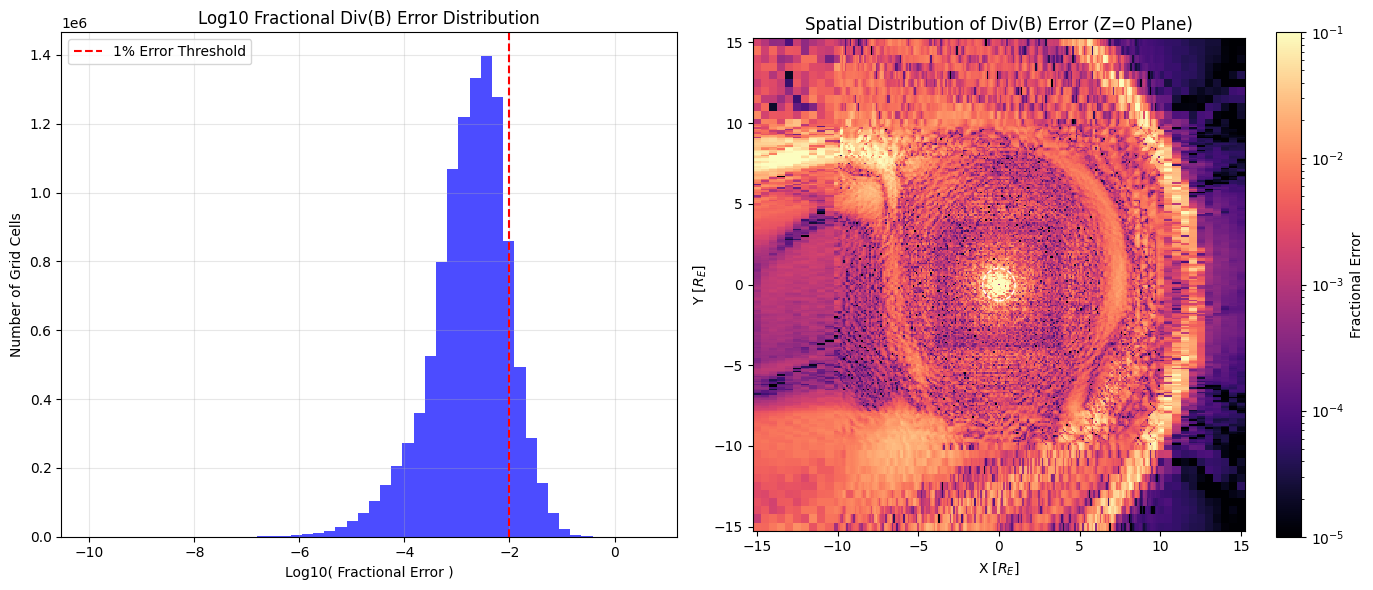

In [2]:
# =============================================================================
# OPTIONAL POST-RUN DIAGNOSTIC: Div(B) Error Check
# Run this cell separately to evaluate the interpolation quality
# =============================================================================
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import os

def analyze_magnetic_divergence_mhd(mhd_dict, x_grid, y_grid, z_grid, t_idx, save_folder="."):
    """Calculates the fractional Div(B) error natively from the loaded Vlasov dict."""
    print(f"\n--- Analyzing Div(B) Error for MHD Data (t_idx = {t_idx}) ---")
    
    # 1. Define bounds in meters
    RE_m = 6.371e6
    limit_m = 15 * RE_m
    
    # 2. Create boolean masks for the -15 to 15 R_E bounds
    x_mask = (x_grid >= -limit_m) & (x_grid <= limit_m)
    y_mask = (y_grid >= -limit_m) & (y_grid <= limit_m)
    z_mask = (z_grid >= -limit_m) & (z_grid <= limit_m)
    
    # 3. Truncate the 1D coordinate grids
    x_grid_trunc = x_grid[x_mask]
    y_grid_trunc = y_grid[y_mask]
    z_grid_trunc = z_grid[z_mask]
    
    # 4. Extract and truncate the 3D data slice using np.ix_
    cube_slice = np.ix_(x_mask, y_mask, z_mask)
    Bx = mhd_dict['Bx'][t_idx][cube_slice]
    By = mhd_dict['By'][t_idx][cube_slice]
    Bz = mhd_dict['Bz'][t_idx][cube_slice]
    
    # 5. Calculate spatial gradients on the truncated cube
    dBx_dx, _, _ = np.gradient(Bx, x_grid_trunc, y_grid_trunc, z_grid_trunc, axis=(0, 1, 2))
    _, dBy_dy, _ = np.gradient(By, x_grid_trunc, y_grid_trunc, z_grid_trunc, axis=(0, 1, 2))
    _, _, dBz_dz = np.gradient(Bz, x_grid_trunc, y_grid_trunc, z_grid_trunc, axis=(0, 1, 2))
    
    div_B = dBx_dx + dBy_dy + dBz_dz
    
    # 6. Calculate B magnitude
    B_mag = np.sqrt(Bx**2 + By**2 + Bz**2)
    B_mag = np.maximum(B_mag, 1e-15) 
    
    # 7. Calculate normalized fractional error (Units cancel out)
    dx_avg = np.mean(np.diff(x_grid_trunc))
    fractional_error = np.abs(div_B) * dx_avg / B_mag
    
    print(f"Mean Fractional Error (-15 to 15 Re): {np.mean(fractional_error):.2e}")
    print(f"Max Fractional Error (-15 to 15 Re):  {np.max(fractional_error):.2e}")
    
    # 8. Visualization
    z_mid = len(z_grid_trunc) // 2
    
    # Convert truncated grid back to Earth Radii for the plot
    X_re, Y_re = np.meshgrid(x_grid_trunc / RE_m, y_grid_trunc / RE_m, indexing='ij')
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    
    # Panel 1: Histogram (Now only reflects data inside the 15 Re cube)
    ax[0].hist(np.log10(fractional_error.flatten() + 1e-10), bins=50, color='blue', alpha=0.7)
    ax[0].axvline(x=-2.0, color='red', linestyle='--', label='1% Error Threshold')
    ax[0].set_title("Log10 Fractional Div(B) Error Distribution")
    ax[0].set_xlabel("Log10( Fractional Error )")
    ax[0].set_ylabel("Number of Grid Cells")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)
    
    # Panel 2: Spatial Slice
    error_slice = fractional_error[:, :, z_mid]
    
    im = ax[1].pcolormesh(X_re, Y_re, error_slice, cmap='magma', 
                          norm=LogNorm(vmin=1e-5, vmax=1e-1))
    ax[1].set_title("Spatial Distribution of Div(B) Error (Z=0 Plane)")
    ax[1].set_xlabel("X [$R_E$]")
    ax[1].set_ylabel("Y [$R_E$]")
    ax[1].set_aspect('equal')
    
    # Earth reference
    earth = plt.Circle((0, 0), 1.0, color='white', fill=False, linestyle='--')
    ax[1].add_patch(earth)
    
    fig.colorbar(im, ax=ax[1], label="Fractional Error")
    plt.tight_layout()
    
    # Save if a run folder exists
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, "DivB_Diagnostic_Truncated.png")
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    print(f"Saved Div(B) Diagnostic to: {save_path}")
    plt.show()


analyze_magnetic_divergence_mhd(mhd_data, grid_x, grid_y, grid_z, t_idx=0, save_folder=run_folder)